# Minimal Live Pipeline: Online Bayesian Meal Response Identification

This notebook is a compact, reusable version of the Mode 2 pipeline. It is organized like a small library:

1. Dataframe -> meal-window samples.
2. Ackerman/state-space meal-response model.
3. Completed-meal A/T posterior labels.
4. Population/person kinetic estimation.
5. Premeal prior learning for A/T.
6. Online Bayesian updating of A/T during a meal.
7. Counterfactual meal recommendations.

The goal is to make each function small enough to reuse in scripts or a live reader. The final demo cell is disabled by default; set `RUN_MINIMAL_DEMO = True` when you want to run a small end-to-end example.

In [14]:
# =========================================================
# Imports and Configuration
# =========================================================

from collections import defaultdict
from pathlib import Path
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "nbs":
    ROOT_DIR = ROOT_DIR.parent

DATA_PATH = ROOT_DIR / "data" / "processed" / "t2d_long_format.csv"
FEATURES_PATH = ROOT_DIR / "data" / "processed" / "extracted_features.csv"

# Switch to "simulated" to test whether the online learner recovers known dynamics.
DATA_SOURCE = "simulated"  # "real" or "simulated"
SIMULATED_DATA_CONFIG = {
    "n_people": 24,
    "meals_per_person": 28,
    "random_state": 7,
    "measurement_sigma": 5.0,
    "process_sigma": 3.0,
}

TIME_GRID = np.arange(-30.0, 181.0, 5.0)

DEFAULT_THETA = {
    "period": 170.0,
    "zeta": 0.70,
    "k_b": 0.001,
    "A0": 0.12,
    "T0": 90.0,
    "pulse_fast_fraction": 0.58,
    "pulse_fast_width_fraction": 0.45,
    "pulse_delay_fraction": 0.30,
    "pulse_edge": 3.0,
}

PARAM_BOUNDS = {
    "A": (0.01, 0.35),
    "T": (15.0, 180.0),
    "period": (80.0, 280.0),
    "zeta": (0.25, 1.75),
}

LABEL_A_GRID = np.linspace(0.01, 0.30, 16)
LABEL_T_GRID = np.linspace(15.0, 165.0, 16)

LABEL_SIGMA = 18.0
LABEL_TEMPERATURE = 0.20
ONLINE_SIGMA = 18.0
ONLINE_EFFECTIVE_INDEPENDENT_MINUTES = 25.0
MODEL_ERROR_SIGMA = 14.0
NORMAL = NormalDist()

In [15]:
# =========================================================
# Dataframe -> Meal-Window Samples
# =========================================================

MEAL_TYPE_MAP = {
    "breakfast": np.array([1.0, 0.0, 0.0]),
    "lunch": np.array([0.0, 1.0, 0.0]),
    "dinner": np.array([0.0, 0.0, 1.0]),
}

NUTRIENT_COLUMN_MAP = {
    "kcal": "Kcal",
    "carbs": "CHO_g",
    "fat": "Fat_g",
    "protein": "Prot_g",
    "fiber": "Fiber_g",
    "sugars": "Sugars_g",
    "saturated_fat": "Saturated fat_g",
    "mufa": "MUFA_g",
    "pufa": "PUFA_g",
    "animal_protein": "Animal_Protein_g",
    "plant_protein": "Plant_protein_g",
    "glycemic_index": "Glycemic_Index",
    "glycemic_load": "Glycemic_Load",
}

PERSON_COVARIATE_COLUMNS = [
    "Age",
    "Sex",
    "BMI",
    "WC_cm",
    "HbA1c_perc",
    "Diabetes duration_years",
    "HOMA_IR",
    "Metformin use",
    "Lipid therapy",
]


def finite_float(value, default=0.0):
    try:
        value = float(value)
    except Exception:
        return float(default)
    if not np.isfinite(value):
        return float(default)
    return float(value)


def clean_response_dataframe(df):
    df = df.copy()
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    df["Glucose"] = pd.to_numeric(df["Glucose"], errors="coerce")
    df["time_meal"] = pd.to_numeric(df["time_meal"], errors="coerce")
    df = df.dropna(subset=["Glucose", "time_meal", "abs_ID", "ID"])
    return df


def extract_meal_nutrients(group):
    row = group.iloc[0]
    meal = {}
    for key, column in NUTRIENT_COLUMN_MAP.items():
        meal[key] = finite_float(row[column], np.nan) if column in group.columns else np.nan

    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal_default = 4.0 * carbs + 9.0 * fat + 4.0 * protein
    meal["kcal"] = finite_float(meal.get("kcal", kcal_default), kcal_default)
    meal["fiber"] = finite_float(meal.get("fiber", 0.0), 0.0)
    meal["sugars"] = finite_float(meal.get("sugars", 0.0), 0.0)
    meal["glycemic_index"] = finite_float(meal.get("glycemic_index", 60.0), 60.0)
    meal["glycemic_load"] = finite_float(meal.get("glycemic_load", carbs * meal["glycemic_index"] / 100.0), carbs * meal["glycemic_index"] / 100.0)
    return meal


def load_person_covariates(features_path=FEATURES_PATH):
    if not Path(features_path).exists():
        return {}

    df = pd.read_csv(features_path)
    if "ID" not in df.columns:
        return {}

    covariates = {}
    for person_id, group in df.groupby("ID"):
        row = group.iloc[0]
        covariates[int(float(person_id))] = {
            column: row[column]
            for column in PERSON_COVARIATE_COLUMNS
            if column in group.columns
        }
    return covariates


def meal_type_vector(meal_type):
    meal_type = str(meal_type).lower()
    return MEAL_TYPE_MAP.get(meal_type, np.zeros(3, dtype=float)).copy()


def is_standardized_test_meal(sample_or_meal):
    meal_type = str(sample_or_meal.get("meal_type", "")).lower()
    meal_id = str(sample_or_meal.get("meal_id", "")).lower()
    return "test" in meal_type or "test" in meal_id


def build_meal_windows(
    df,
    t_grid=TIME_GRID,
    min_pre_time=-25.0,
    min_post_time=120.0,
    require_full_grid=True,
    person_covariates=None,
):
    """Convert the long CGM dataframe into simple sample dictionaries."""
    df = clean_response_dataframe(df)
    person_covariates = person_covariates or {}
    windows = []

    for meal_id, group in df.groupby("abs_ID"):
        group = group.sort_values("time_meal")
        time_raw = group["time_meal"].to_numpy(dtype=float)
        glucose_raw = group["Glucose"].to_numpy(dtype=float)
        ok = np.isfinite(time_raw) & np.isfinite(glucose_raw)
        time_raw = time_raw[ok]
        glucose_raw = glucose_raw[ok]
        if len(time_raw) < 8:
            continue
        if np.nanmin(time_raw) > min_pre_time or np.nanmax(time_raw) < min_post_time:
            continue
        if require_full_grid and (np.nanmin(time_raw) > np.nanmin(t_grid) or np.nanmax(time_raw) < np.nanmax(t_grid)):
            continue

        order = np.argsort(time_raw)
        time_raw = time_raw[order]
        glucose_raw = glucose_raw[order]
        glucose = np.interp(t_grid, time_raw, glucose_raw)

        person_id = int(float(group["ID"].iloc[0]))
        meal_type = str(group["Meal type"].iloc[0])
        context = np.r_[0.0, 0.0, meal_type_vector(meal_type)]

        windows.append({
            "idx": len(windows),
            "person_id": person_id,
            "original_person_id": person_id,
            "meal_id": str(meal_id),
            "meal_type": meal_type,
            "day": int(finite_float(group["Day number"].iloc[0], 0.0)) if "Day number" in group.columns else -1,
            "meal": extract_meal_nutrients(group),
            "context": context.astype(float),
            "person_covariates": person_covariates.get(person_id, {}),
            "time": np.asarray(t_grid, dtype=float),
            "glucose": np.asarray(glucose, dtype=float),
        })

    return windows


def load_live_windows(data_path=DATA_PATH, features_path=FEATURES_PATH):
    df = pd.read_csv(data_path)
    covariates = load_person_covariates(features_path)
    windows = build_meal_windows(df, person_covariates=covariates)
    return df, windows


def split_meals_by_person(windows, train_frac=0.70, min_train=5, min_test=2, random_state=0):
    rng = np.random.default_rng(random_state)
    by_person = defaultdict(list)
    for idx, sample in enumerate(windows):
        by_person[int(sample["person_id"])].append(idx)

    train_idx, test_idx = [], []
    for person_id, indices in by_person.items():
        indices = np.asarray(indices, dtype=int)
        rng.shuffle(indices)
        if len(indices) < min_train + min_test:
            continue
        n_train = int(np.clip(round(train_frac * len(indices)), min_train, len(indices) - min_test))
        train_idx.extend(indices[:n_train].tolist())
        test_idx.extend(indices[n_train:].tolist())

    return sorted(train_idx), sorted(test_idx)


def sample_with_meal(sample, meal):
    new_sample = dict(sample)
    new_sample["meal"] = dict(meal)
    return new_sample

In [16]:
# =========================================================
# Model Primitives
# =========================================================


def merge_theta(theta=None):
    merged = dict(DEFAULT_THETA)
    if theta:
        merged.update(theta)
    merged["period"] = float(np.clip(merged["period"], *PARAM_BOUNDS["period"]))
    merged["zeta"] = float(np.clip(merged["zeta"], *PARAM_BOUNDS["zeta"]))
    merged["k_b"] = float(max(0.0, merged.get("k_b", 0.001)))
    return merged


def premeal_summary(sample):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = time < 0
    if np.any(pre):
        t_pre = time[pre]
        g_pre = glucose[pre]
        baseline = float(np.median(g_pre))
        slope = float(np.polyfit(t_pre, g_pre, 1)[0]) if len(t_pre) >= 2 else 0.0
        last_level = float(g_pre[-1])
        delta_30 = float(g_pre[-1] - g_pre[0]) if len(g_pre) >= 2 else 0.0
        pre_std = float(np.std(g_pre))
        pre_range = float(np.max(g_pre) - np.min(g_pre))
    else:
        baseline = float(glucose[0])
        slope = 0.0
        last_level = baseline
        delta_30 = 0.0
        pre_std = 0.0
        pre_range = 0.0

    return {
        "baseline": baseline,
        "slope": slope,
        "last_level": last_level,
        "delta_30": delta_30,
        "std": pre_std,
        "range": pre_range,
    }


def response_metrics(time, curve, baseline=None, threshold=180.0):
    time = np.asarray(time, dtype=float)
    curve = np.asarray(curve, dtype=float)
    if baseline is None:
        baseline = float(np.median(curve[time < 0])) if np.any(time < 0) else float(curve[0])
    post = time >= 0
    post_time = time[post]
    post_curve = curve[post]
    above_base = post_curve - baseline
    return {
        "baseline": float(baseline),
        "peak": float(np.max(post_curve)),
        "peak_delta": float(np.max(post_curve) - baseline),
        "iAUC": float(np.trapz(np.maximum(above_base, 0.0), post_time)) if len(post_time) else 0.0,
        "time_above_180": float(np.sum(post_curve > threshold) * np.nanmedian(np.diff(time))) if len(time) > 1 else 0.0,
    }


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype=float)))


def finite_width_pulse(t, width, edge=3.0):
    if t < 0:
        return 0.0
    width = max(float(width), 1e-6)
    edge = max(float(edge), 1e-6)
    return float(sigmoid(t / edge) * sigmoid((width - t) / edge))


def asymmetric_meal_pulse(t, T, theta=None):
    """Two-component smooth pulse with one interpretable width parameter T."""
    theta = merge_theta(theta)
    if t < 0:
        return 0.0

    rho = float(np.clip(theta.get("pulse_fast_fraction", 0.58), 0.0, 1.0))
    fast_width = max(float(theta.get("pulse_fast_width_fraction", 0.45)) * T, 1.0)
    delay = max(float(theta.get("pulse_delay_fraction", 0.30)) * T, 0.0)
    slow_width = max(T - delay, 1.0)
    edge = float(theta.get("pulse_edge", 3.0))

    fast = finite_width_pulse(t, fast_width, edge=edge)
    slow = finite_width_pulse(t - delay, slow_width, edge=edge * 1.5)
    return rho * fast + (1.0 - rho) * slow


def rollout_meal_response(sample, theta=None, A=None, T=None):
    """Deterministic Ackerman-style rollout for one fixed A/T pair."""
    theta = merge_theta(theta)
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = premeal_summary(sample)

    A = DEFAULT_THETA["A0"] if A is None else float(A)
    T = DEFAULT_THETA["T0"] if T is None else float(T)
    A = float(np.clip(A, *PARAM_BOUNDS["A"]))
    T = float(np.clip(T, *PARAM_BOUNDS["T"]))

    omega = 2.0 * np.pi / theta["period"]
    zeta = theta["zeta"]
    k_b = theta["k_b"]

    # State: G deviation, V velocity, B baseline.
    state = np.array([glucose[0] - pre["baseline"], pre["slope"], pre["baseline"]], dtype=float)
    pred = []

    for i, t in enumerate(time):
        pred.append(float(state[0] + state[2]))
        if i == len(time) - 1:
            break

        dt = float(time[i + 1] - time[i])
        n_steps = max(1, int(np.ceil(abs(dt))))
        h = dt / n_steps

        for substep in range(n_steps):
            t_sub = float(t) + substep * h
            G, V, B = state
            u = A * asymmetric_meal_pulse(t_sub, T, theta=theta)
            dG = V
            dV = -(omega ** 2) * G - 2.0 * zeta * omega * V + u
            dB = -k_b * (B - pre["baseline"])
            state = np.array([G + h * dG, V + h * dV, B + h * dB], dtype=float)

    return np.asarray(pred, dtype=float)


# =========================================================
# Simulated Data Source for Pipeline Diagnostics
# =========================================================


def simulate_person_covariates(rng, person_id):
    metformin = int(rng.random() < 0.55)
    age = int(np.clip(rng.normal(62.0, 8.0), 38.0, 82.0))
    bmi = float(np.clip(rng.normal(30.0, 4.5), 20.0, 45.0))
    return {
        "Age": age,
        "Sex": int(rng.random() < 0.50),
        "BMI": bmi,
        "WC_cm": float(np.clip(72.0 + 1.2 * bmi + rng.normal(0.0, 8.0), 75.0, 145.0)),
        "HbA1c_perc": float(np.clip(rng.normal(6.9, 0.8), 5.2, 10.5)),
        "Diabetes duration_years": float(np.clip(rng.gamma(2.0, 3.0), 0.2, 25.0)),
        "HOMA_IR": float(np.clip(rng.lognormal(np.log(3.2), 0.45), 0.5, 12.0)),
        "Metformin use": metformin,
        "Lipid therapy": int(rng.random() < 0.45),
    }


def simulate_person_traits(rng, person_id):
    meal_types = list(MEAL_TYPE_MAP.keys())
    return {
        "period": float(np.clip(rng.normal(170.0, 14.0), *PARAM_BOUNDS["period"])),
        "zeta": float(np.clip(rng.normal(0.70, 0.10), *PARAM_BOUNDS["zeta"])),
        "baseline": float(np.clip(rng.normal(118.0, 18.0), 80.0, 175.0)),
        "log_A_offset": float(rng.normal(0.0, 0.18)),
        "log_T_offset": float(rng.normal(0.0, 0.15)),
        "cat_log_A": {meal_type: float(rng.normal(0.0, 0.08)) for meal_type in meal_types},
        "cat_log_T": {meal_type: float(rng.normal(0.0, 0.10)) for meal_type in meal_types},
    }


def simulate_meal_nutrients(rng, meal_type):
    params = {
        "breakfast": {"carbs": (48.0, 16.0), "fat": (14.0, 8.0), "protein": (18.0, 7.0)},
        "lunch": {"carbs": (68.0, 24.0), "fat": (22.0, 12.0), "protein": (30.0, 12.0)},
        "dinner": {"carbs": (76.0, 28.0), "fat": (30.0, 14.0), "protein": (34.0, 13.0)},
    }[meal_type]

    carbs = float(np.clip(rng.normal(*params["carbs"]), 12.0, 165.0))
    fat = float(np.clip(rng.normal(*params["fat"]), 2.0, 90.0))
    protein = float(np.clip(rng.normal(*params["protein"]), 4.0, 95.0))
    fiber = float(np.clip(rng.normal(0.10 * carbs, 3.5), 0.0, min(25.0, carbs)))
    sugars = float(np.clip(rng.normal(0.28 * carbs, 8.0), 0.0, carbs))
    saturated_fat = float(np.clip(rng.normal(0.32 * fat, 3.0), 0.0, fat))
    mufa = float(np.clip(rng.normal(0.38 * fat, 4.0), 0.0, fat))
    pufa = float(np.clip(fat - saturated_fat - mufa, 0.0, fat))
    animal_protein = float(np.clip(rng.normal(0.62 * protein, 8.0), 0.0, protein))
    plant_protein = float(np.clip(protein - animal_protein, 0.0, protein))
    glycemic_index = float(np.clip(58.0 + 0.12 * sugars - 0.55 * fiber + rng.normal(0.0, 7.0), 35.0, 90.0))
    glycemic_load = float(carbs * glycemic_index / 100.0)
    kcal = float(4.0 * carbs + 9.0 * fat + 4.0 * protein)

    return {
        "kcal": kcal,
        "carbs": carbs,
        "fat": fat,
        "protein": protein,
        "fiber": fiber,
        "sugars": sugars,
        "saturated_fat": saturated_fat,
        "mufa": mufa,
        "pufa": pufa,
        "animal_protein": animal_protein,
        "plant_protein": plant_protein,
        "glycemic_index": glycemic_index,
        "glycemic_load": glycemic_load,
    }


def simulated_true_at(meal, meal_type, pre_baseline, pre_slope, traits, rng):
    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    fiber = finite_float(meal.get("fiber", 0.0))
    sugars = finite_float(meal.get("sugars", 0.0))
    kcal = max(finite_float(meal.get("kcal", 1.0)), 1.0)
    glycemic_load = finite_float(meal.get("glycemic_load", carbs * 0.60))

    type_A = {"breakfast": 0.14, "lunch": 0.02, "dinner": -0.09}.get(meal_type, 0.0)
    type_T = {"breakfast": -0.10, "lunch": 0.00, "dinner": 0.16}.get(meal_type, 0.0)

    z_carbs = (carbs - 70.0) / 50.0
    z_fat = (fat - 20.0) / 15.0
    z_protein = (protein - 25.0) / 15.0
    z_gl = (glycemic_load - 35.0) / 25.0
    z_sugars = (sugars - 15.0) / 12.0
    z_fiber = (fiber - 6.0) / 5.0
    z_kcal = (kcal - 550.0) / 300.0
    z_pre = (pre_baseline - 120.0) / 40.0

    log_A = (
        np.log(0.12)
        + traits["log_A_offset"]
        + traits["cat_log_A"].get(meal_type, 0.0)
        + type_A
        + 0.32 * z_carbs
        + 0.18 * z_gl
        + 0.06 * z_sugars
        - 0.07 * z_fat
        + 0.05 * z_pre
        + rng.normal(0.0, 0.08)
    )
    log_T = (
        np.log(88.0)
        + traits["log_T_offset"]
        + traits["cat_log_T"].get(meal_type, 0.0)
        + type_T
        + 0.34 * z_fat
        + 0.14 * z_protein
        + 0.12 * z_kcal
        - 0.09 * z_fiber
        + 0.04 * pre_slope / 0.20
        + rng.normal(0.0, 0.09)
    )

    return {
        "A": float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"])),
    }


def dataframe_rows_for_simulated_sample(sample):
    meal = sample["meal"]
    rows = []
    for t, g in zip(sample["time"], sample["glucose"]):
        row = {
            "ID": int(sample["person_id"]),
            "abs_ID": sample["meal_id"],
            "Meal type": sample["meal_type"],
            "Day number": int(sample.get("day", -1)),
            "time_meal": float(t),
            "Glucose": float(g),
            "true_A": float(sample.get("true_A", np.nan)),
            "true_T": float(sample.get("true_T", np.nan)),
            "true_period": float(sample.get("true_period", np.nan)),
            "true_zeta": float(sample.get("true_zeta", np.nan)),
        }
        for key, column in NUTRIENT_COLUMN_MAP.items():
            row[column] = finite_float(meal.get(key, np.nan), np.nan)
        rows.append(row)
    return rows


def load_simulated_windows(config=None, **overrides):
    config = {**SIMULATED_DATA_CONFIG, **(config or {}), **overrides}
    rng = np.random.default_rng(int(config.get("random_state", 7)))
    n_people = int(config.get("n_people", 24))
    meals_per_person = int(config.get("meals_per_person", 28))
    measurement_sigma = float(config.get("measurement_sigma", 5.0))
    process_sigma = float(config.get("process_sigma", 3.0))

    meal_types = np.asarray(["breakfast", "lunch", "dinner"], dtype=object)
    meal_probs = np.asarray([0.32, 0.38, 0.30], dtype=float)
    windows = []
    rows = []

    for person_id in range(n_people):
        traits = simulate_person_traits(rng, person_id)
        covariates = simulate_person_covariates(rng, person_id)
        for meal_order in range(meals_per_person):
            meal_type = str(rng.choice(meal_types, p=meal_probs))
            meal = simulate_meal_nutrients(rng, meal_type)
            day = 1 + meal_order // 3
            meal_id = f"sim_{person_id}_{meal_type}_{meal_order + 1}"

            baseline = float(traits["baseline"] + 5.0 * np.sin(2.0 * np.pi * meal_order / 18.0) + rng.normal(0.0, 7.0))
            pre_slope = float(rng.normal(0.0, 0.08))
            time = np.asarray(TIME_GRID, dtype=float)
            glucose_seed = np.full_like(time, baseline, dtype=float)
            pre_mask = time < 0
            glucose_seed[pre_mask] = baseline + pre_slope * time[pre_mask] + rng.normal(0.0, 1.0, size=int(pre_mask.sum()))

            sample = {
                "idx": len(windows),
                "person_id": int(person_id),
                "original_person_id": int(person_id),
                "meal_id": meal_id,
                "meal_type": meal_type,
                "day": int(day),
                "meal": meal,
                "context": np.r_[0.0, 0.0, meal_type_vector(meal_type)].astype(float),
                "person_covariates": covariates,
                "time": time,
                "glucose": glucose_seed,
                "simulated": True,
            }

            pre = premeal_summary(sample)
            true_at = simulated_true_at(meal, meal_type, pre["baseline"], pre["slope"], traits, rng)
            theta = {"period": traits["period"], "zeta": traits["zeta"], "k_b": DEFAULT_THETA["k_b"]}
            clean = rollout_meal_response(sample, theta=theta, A=true_at["A"], T=true_at["T"])
            smooth_noise = np.convolve(rng.normal(0.0, process_sigma, size=len(time)), np.ones(5) / 5.0, mode="same")
            glucose = clean + smooth_noise + rng.normal(0.0, measurement_sigma, size=len(time))

            sample["glucose"] = np.asarray(glucose, dtype=float)
            sample["true_A"] = float(true_at["A"])
            sample["true_T"] = float(true_at["T"])
            sample["true_period"] = float(traits["period"])
            sample["true_zeta"] = float(traits["zeta"])
            sample["true_baseline"] = float(baseline)

            windows.append(sample)
            rows.extend(dataframe_rows_for_simulated_sample(sample))

    return pd.DataFrame(rows), windows


def simulated_truth_table(windows):
    rows = []
    for sample in windows:
        if not sample.get("simulated", False):
            continue
        rows.append({
            "idx": int(sample["idx"]),
            "person_id": int(sample["person_id"]),
            "meal_id": sample["meal_id"],
            "meal_type": sample["meal_type"],
            "true_A": float(sample["true_A"]),
            "true_T": float(sample["true_T"]),
            "true_period": float(sample["true_period"]),
            "true_zeta": float(sample["true_zeta"]),
            **{key: finite_float(sample["meal"].get(key, np.nan), np.nan) for key in ["carbs", "fat", "protein", "kcal", "fiber", "glycemic_load"]},
        })
    return pd.DataFrame(rows)


def load_pipeline_windows(data_source=DATA_SOURCE, **simulated_overrides):
    source = str(data_source).strip().lower()
    if source in {"real", "observed", "data"}:
        return load_live_windows()
    if source in {"sim", "simulated", "synthetic"}:
        return load_simulated_windows(**simulated_overrides)
    raise ValueError(f"Unknown DATA_SOURCE={data_source!r}; use 'real' or 'simulated'.")

In [17]:
# =========================================================
# Bayesian Utilities and Completed-Meal A/T Labels
# =========================================================


def logsumexp(values):
    values = np.asarray(values, dtype=float)
    m = np.max(values)
    return float(m + np.log(np.sum(np.exp(values - m))))


def softmax_log(log_values):
    log_values = np.asarray(log_values, dtype=float)
    return np.exp(log_values - logsumexp(log_values))


def weighted_quantile(values, weights, probs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    probs = np.asarray(probs, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = np.maximum(weights[order], 0.0)
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    cdf = np.cumsum(weights) / np.sum(weights)
    return np.interp(probs, cdf, values)


def posterior_at_summary(A_grid, T_grid, posterior):
    posterior = np.asarray(posterior, dtype=float)
    posterior = posterior / np.sum(posterior)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)
    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)
    A_mean = float(np.sum(posterior * A_grid[None, :]))
    T_mean = float(np.sum(posterior * T_grid[:, None]))
    A_sd = float(np.sqrt(np.sum(posterior * (A_grid[None, :] - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(posterior * (T_grid[:, None] - T_mean) ** 2)))
    return {
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "posterior_entropy": float(-np.sum(posterior * np.log(np.clip(posterior, 1e-300, None)))),
    }


def infer_completed_at_posterior(
    sample,
    theta=None,
    A_grid=LABEL_A_GRID,
    T_grid=LABEL_T_GRID,
    sigma=LABEL_SIGMA,
    likelihood_temperature=LABEL_TEMPERATURE,
):
    """Posterior p(A,T | full completed CGM curve) for one historical meal."""
    theta = merge_theta(theta)
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    post = time >= 0

    logpost = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    trajectories = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for ti, T in enumerate(T_grid):
        for ai, A in enumerate(A_grid):
            pred = rollout_meal_response(sample, theta=theta, A=float(A), T=float(T))
            trajectories[ti, ai] = pred
            resid = glucose[post] - pred[post]
            logpost[ti, ai] = -0.5 * likelihood_temperature * float(np.sum((resid / sigma) ** 2))

    posterior = softmax_log(logpost)
    pred_mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))
    summary = posterior_at_summary(A_grid, T_grid, posterior)
    summary.update({
        "label_rmse": float(np.sqrt(np.mean((pred_mean[post] - glucose[post]) ** 2))),
        "posterior": posterior,
        "pred_mean": pred_mean,
    })
    return summary


def estimate_at_labels(windows, indices, theta_by_person=None, population_theta=None, max_meals=200, random_state=0):
    """Infer completed-meal A/T labels for a subset of windows."""
    rng = np.random.default_rng(random_state)
    indices = np.asarray(list(indices), dtype=int)
    if len(indices) > max_meals:
        indices = rng.choice(indices, size=max_meals, replace=False)
    indices = sorted(map(int, indices))
    theta_by_person = theta_by_person or {}
    population_theta = merge_theta(population_theta)

    rows = []
    for idx in tqdm(indices, desc="A/T labels"):
        sample = windows[int(idx)]
        theta = theta_by_person.get(int(sample["person_id"]), population_theta)
        label = infer_completed_at_posterior(sample, theta=theta)
        rows.append({
            "idx": int(idx),
            "person_id": int(sample["person_id"]),
            "meal_id": sample["meal_id"],
            "meal_type": sample["meal_type"],
            "A_mean": label["A_mean"],
            "T_mean": label["T_mean"],
            "A_sd": label["A_sd"],
            "T_sd": label["T_sd"],
            "A_map": label["A_map"],
            "T_map": label["T_map"],
            "posterior_entropy": label["posterior_entropy"],
            "label_rmse": label["label_rmse"],
        })
    return pd.DataFrame(rows)

In [18]:
# =========================================================
# Kinetic Estimation Using Completed-Meal A/T Labels
# =========================================================


def pack_kinetics(theta):
    theta = merge_theta(theta)
    return np.log([theta["period"], theta["zeta"]])


def unpack_kinetics(params, base_theta=None):
    theta = merge_theta(base_theta)
    values = np.exp(np.asarray(params, dtype=float))
    theta["period"] = float(np.clip(values[0], *PARAM_BOUNDS["period"]))
    theta["zeta"] = float(np.clip(values[1], *PARAM_BOUNDS["zeta"]))
    return theta


def kinetic_prior_penalty(theta, prior_theta):
    theta = merge_theta(theta)
    prior_theta = merge_theta(prior_theta)
    period_z = np.log(theta["period"] / prior_theta["period"]) / 0.25
    zeta_z = np.log(theta["zeta"] / prior_theta["zeta"]) / 0.35
    return float(period_z ** 2 + zeta_z ** 2)


def kinetic_loss(params, windows, labels_df, base_theta=None, prior_theta=None, prior_weight=0.0):
    theta = unpack_kinetics(params, base_theta=base_theta)
    losses = []

    for row in labels_df.itertuples(index=False):
        sample = windows[int(row.idx)]
        time = np.asarray(sample["time"], dtype=float)
        glucose = np.asarray(sample["glucose"], dtype=float)
        post = time >= 0
        baseline = premeal_summary(sample)["baseline"]

        pred = rollout_meal_response(sample, theta=theta, A=float(row.A_mean), T=float(row.T_mean))
        obs_metrics = response_metrics(time, glucose, baseline=baseline)
        pred_metrics = response_metrics(time, pred, baseline=baseline)
        post_duration = max(float(time[post][-1] - time[post][0]), 1.0)

        curve_mse = float(np.mean((pred[post] - glucose[post]) ** 2))
        peak_mse = float((pred_metrics["peak"] - obs_metrics["peak"]) ** 2)
        iauc_mse = float(((pred_metrics["iAUC"] - obs_metrics["iAUC"]) / post_duration) ** 2)
        losses.append(curve_mse + 0.5 * peak_mse + 0.25 * iauc_mse)

    if not losses:
        return 1e9

    loss = float(np.mean(losses))
    if prior_theta is not None and prior_weight > 0:
        loss += float(prior_weight) * kinetic_prior_penalty(theta, prior_theta)
    return loss


def fit_kinetics(windows, labels_df, base_theta=None, prior_theta=None, prior_weight=20.0, maxiter=60):
    """Fit period and zeta for a set of completed meal labels."""
    base_theta = merge_theta(base_theta)
    prior_theta = merge_theta(prior_theta or base_theta)
    result = minimize(
        lambda p: kinetic_loss(
            p,
            windows=windows,
            labels_df=labels_df,
            base_theta=base_theta,
            prior_theta=prior_theta,
            prior_weight=prior_weight,
        ),
        x0=pack_kinetics(base_theta),
        bounds=[
            (np.log(PARAM_BOUNDS["period"][0]), np.log(PARAM_BOUNDS["period"][1])),
            (np.log(PARAM_BOUNDS["zeta"][0]), np.log(PARAM_BOUNDS["zeta"][1])),
        ],
        method="L-BFGS-B",
        options={"maxiter": int(maxiter)},
    )
    return unpack_kinetics(result.x, base_theta=base_theta), result


def fit_population_and_person_kinetics(
    windows,
    labels_df,
    min_person_meals=5,
    person_prior_weight=120.0,
    population_prior_weight=20.0,
):
    """Fit population kinetics, then shrink person kinetics toward population."""
    population_theta, population_result = fit_kinetics(
        windows,
        labels_df,
        base_theta=DEFAULT_THETA,
        prior_theta=DEFAULT_THETA,
        prior_weight=population_prior_weight,
    )

    person_thetas = {}
    diagnostics = []
    for person_id, group in labels_df.groupby("person_id"):
        if len(group) < min_person_meals:
            person_thetas[int(person_id)] = population_theta
            diagnostics.append({
                "person_id": int(person_id),
                "n_meals": len(group),
                "period": population_theta["period"],
                "zeta": population_theta["zeta"],
                "success": True,
                "used_population_fallback": True,
            })
            continue

        theta_i, result_i = fit_kinetics(
            windows,
            group,
            base_theta=population_theta,
            prior_theta=population_theta,
            prior_weight=person_prior_weight,
            maxiter=45,
        )
        person_thetas[int(person_id)] = theta_i
        diagnostics.append({
            "person_id": int(person_id),
            "n_meals": len(group),
            "period": theta_i["period"],
            "zeta": theta_i["zeta"],
            "loss": float(result_i.fun),
            "success": bool(result_i.success),
            "used_population_fallback": False,
        })

    return population_theta, person_thetas, pd.DataFrame(diagnostics), population_result


def theta_for_sample(sample, population_theta, person_thetas=None):
    person_thetas = person_thetas or {}
    return person_thetas.get(int(sample["person_id"]), population_theta)

In [19]:
# =========================================================
# Premeal Prior Learning for A/T
# =========================================================

FEATURE_NAMES = [
    "intercept",
    "carbs",
    "net_carbs",
    "sugars",
    "fiber",
    "fat",
    "saturated_fat",
    "protein",
    "glycemic_load",
    "kcal",
    "carb_kcal_fraction",
    "fat_kcal_fraction",
    "protein_kcal_fraction",
    "premeal_level",
    "premeal_slope",
    "breakfast",
    "lunch",
    "dinner",
]


def meal_feature_vector(sample):
    meal = sample["meal"]
    pre = premeal_summary(sample)
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)

    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal = max(finite_float(meal.get("kcal", 4.0 * carbs + 9.0 * fat + 4.0 * protein)), 1.0)
    fiber = np.clip(finite_float(meal.get("fiber", 0.0)), 0.0, max(carbs, 0.0))
    sugars = np.clip(finite_float(meal.get("sugars", 0.0)), 0.0, max(carbs, 0.0))
    net_carbs = max(carbs - fiber, 0.0)
    saturated_fat = np.clip(finite_float(meal.get("saturated_fat", 0.0)), 0.0, max(fat, 0.0))
    glycemic_index = finite_float(meal.get("glycemic_index", 60.0), 60.0)
    glycemic_load = finite_float(meal.get("glycemic_load", carbs * glycemic_index / 100.0), carbs * glycemic_index / 100.0)

    return np.asarray([
        1.0,
        (carbs - 70.0) / 50.0,
        (net_carbs - 60.0) / 45.0,
        (sugars - 15.0) / 12.0,
        (fiber - 6.0) / 5.0,
        (fat - 20.0) / 15.0,
        (saturated_fat - 6.0) / 6.0,
        (protein - 25.0) / 15.0,
        (glycemic_load - 35.0) / 25.0,
        (kcal - 550.0) / 300.0,
        (4.0 * carbs / kcal - 0.45) / 0.20,
        (9.0 * fat / kcal - 0.35) / 0.20,
        (4.0 * protein / kcal - 0.20) / 0.15,
        (pre["baseline"] - 120.0) / 40.0,
        pre["slope"] / 0.20,
        *meal_type,
    ], dtype=float)


def fit_ridge(X, y, l2=5.0, sample_weight=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if sample_weight is None:
        W = np.ones(len(y), dtype=float)
    else:
        W = np.asarray(sample_weight, dtype=float)
        W = W / max(float(np.mean(W)), 1e-12)
    Xw = X * np.sqrt(W[:, None])
    yw = y * np.sqrt(W)
    penalty = float(l2) * np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    if weights is None:
        return float(np.std(values))
    weights = np.asarray(weights, dtype=float)
    weights = np.maximum(weights, 0.0)
    weights = weights / max(float(weights.sum()), 1e-12)
    mean = float(np.sum(weights * values))
    return float(np.sqrt(np.sum(weights * (values - mean) ** 2)))


def label_weights(labels_df):
    entropy = labels_df["posterior_entropy"].to_numpy(dtype=float)
    max_entropy = np.log(len(LABEL_A_GRID) * len(LABEL_T_GRID))
    reliability = 1.0 - np.clip(entropy / max_entropy, 0.0, 1.0)
    return 0.25 + 0.75 * reliability


def fit_person_offsets(windows, labels_df, coef_A, coef_T, shrink=8.0):
    offsets = {}
    for person_id, group in labels_df.groupby("person_id"):
        rows = []
        for row in group.itertuples(index=False):
            x = meal_feature_vector(windows[int(row.idx)])
            rows.append({
                "resid_A": np.log(float(row.A_mean)) - float(x @ coef_A),
                "resid_T": np.log(float(row.T_mean)) - float(x @ coef_T),
            })
        residuals = pd.DataFrame(rows)
        n = len(residuals)
        offsets[int(person_id)] = {
            "log_A_offset": float(residuals["resid_A"].sum() / (n + shrink)),
            "log_T_offset": float(residuals["resid_T"].sum() / (n + shrink)),
            "n_offset_meals": int(n),
        }
    return offsets


def apply_simple_biological_constraints(coef_A, coef_T):
    coef_A = np.asarray(coef_A, dtype=float).copy()
    coef_T = np.asarray(coef_T, dtype=float).copy()
    idx = {name: i for i, name in enumerate(FEATURE_NAMES)}

    for name in ["carbs", "net_carbs", "sugars", "glycemic_load", "carb_kcal_fraction"]:
        coef_A[idx[name]] = max(0.0, coef_A[idx[name]])
    for name in ["fat", "saturated_fat", "protein", "fiber", "fat_kcal_fraction"]:
        coef_T[idx[name]] = max(0.0, coef_T[idx[name]])

    return coef_A, coef_T


def fit_at_prior(windows, labels_df, l2=5.0, constrain=True, person_offset_shrink=8.0):
    X = np.vstack([meal_feature_vector(windows[int(idx)]) for idx in labels_df["idx"]])
    y_A = np.log(np.clip(labels_df["A_mean"].to_numpy(dtype=float), *PARAM_BOUNDS["A"]))
    y_T = np.log(np.clip(labels_df["T_mean"].to_numpy(dtype=float), *PARAM_BOUNDS["T"]))
    w = label_weights(labels_df)

    coef_A = fit_ridge(X, y_A, l2=l2, sample_weight=w)
    coef_T = fit_ridge(X, y_T, l2=l2, sample_weight=w)
    if constrain:
        coef_A, coef_T = apply_simple_biological_constraints(coef_A, coef_T)

    offsets = fit_person_offsets(windows, labels_df, coef_A, coef_T, shrink=person_offset_shrink)
    resid_A = y_A - X @ coef_A
    resid_T = y_T - X @ coef_T

    return {
        "feature_names": FEATURE_NAMES,
        "coef_log_A": coef_A,
        "coef_log_T": coef_T,
        "person_offsets": offsets,
        "A_log_sd": max(0.35, 1.20 * weighted_std(resid_A, w)),
        "T_log_sd": max(0.35, 1.20 * weighted_std(resid_T, w)),
    }


def predict_at_prior(sample, prior_model):
    x = meal_feature_vector(sample)
    person_id = int(sample["person_id"])
    offset = prior_model.get("person_offsets", {}).get(person_id, {})
    log_A = float(x @ prior_model["coef_log_A"] + offset.get("log_A_offset", 0.0))
    log_T = float(x @ prior_model["coef_log_T"] + offset.get("log_T_offset", 0.0))
    return {
        "A": float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": float(prior_model.get("A_log_sd", 0.55)),
        "T_log_sd": float(prior_model.get("T_log_sd", 0.55)),
        "features": x,
    }

In [20]:
# =========================================================
# Online Bayesian A/T Updating
# =========================================================


def make_log_grid(center, lower, upper, n=35, factor_low=0.25, factor_high=4.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center * factor_low)
    hi = min(upper, center * factor_high)
    if hi <= lo:
        lo, hi = lower, upper
    return np.exp(np.linspace(np.log(lo), np.log(hi), int(n)))


def make_linear_grid(center, lower, upper, n=35, width=70.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center - width)
    hi = min(upper, center + width)
    if hi <= lo:
        lo, hi = lower, upper
    return np.linspace(lo, hi, int(n))


def prediction_grids_from_prior(prior, n_A=35, n_T=35):
    A_sd = float(prior.get("A_log_sd", 0.55))
    T_sd = float(prior.get("T_log_sd", 0.55))
    A_grid = make_log_grid(
        prior["A"],
        *PARAM_BOUNDS["A"],
        n=n_A,
        factor_low=max(0.10, np.exp(-3.0 * A_sd)),
        factor_high=min(8.0, np.exp(3.0 * A_sd)),
    )
    T_width = max(35.0, prior["T"] * (np.exp(2.5 * T_sd) - 1.0))
    T_grid = make_linear_grid(prior["T"], *PARAM_BOUNDS["T"], n=n_T, width=T_width)
    return A_grid, T_grid


def build_log_prior(A_grid, T_grid, prior):
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)
    A_sd = float(prior.get("A_log_sd", 0.55))
    T_sd = float(prior.get("T_log_sd", 0.55))
    log_A = np.log(A_grid)
    log_T = np.log(T_grid)
    log_prior = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    log_prior += -0.5 * ((log_A[None, :] - np.log(prior["A"])) / A_sd) ** 2
    log_prior += -0.5 * ((log_T[:, None] - np.log(prior["T"])) / T_sd) ** 2
    return log_prior - logsumexp(log_prior)


def online_at_posterior(
    sample,
    theta,
    prior,
    n_A=35,
    n_T=35,
    sigma=ONLINE_SIGMA,
    update_start=0.0,
    effective_independent_minutes=ONLINE_EFFECTIVE_INDEPENDENT_MINUTES,
    model_error_sigma=MODEL_ERROR_SIGMA,
):
    """Online posterior over fixed meal parameters p(A,T | CGM up to time t)."""
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    A_grid, T_grid = prediction_grids_from_prior(prior, n_A=n_A, n_T=n_T)

    median_dt = float(np.nanmedian(np.abs(np.diff(time)))) if len(time) > 1 else 5.0
    temperature = float(np.clip(median_dt / max(effective_independent_minutes, 1e-6), 0.02, 1.0))

    trajectories = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)
    for ti, T in enumerate(T_grid):
        for ai, A in enumerate(A_grid):
            trajectories[ti, ai] = rollout_meal_response(sample, theta=theta, A=float(A), T=float(T))

    logpost = build_log_prior(A_grid, T_grid, prior)
    posterior_history = []

    for k, t in enumerate(time):
        if t >= update_start:
            resid = glucose[k] - trajectories[:, :, k]
            logpost = logpost - 0.5 * temperature * (resid / sigma) ** 2
        logpost = logpost - logsumexp(logpost)
        posterior_history.append(np.exp(logpost).copy())

    posterior_history = np.asarray(posterior_history)
    return {
        "time": time,
        "glucose": glucose,
        "A_grid": A_grid,
        "T_grid": T_grid,
        "prior": prior,
        "theta": theta,
        "trajectory_array": trajectories,
        "posterior_history": posterior_history,
        "temperature": temperature,
        "sigma": sigma,
        "model_error_sigma": float(model_error_sigma),
    }


def posterior_predictive(result, posterior_idx=-1, q=(0.05, 0.50, 0.95)):
    posterior = result["posterior_history"][posterior_idx]
    trajectories = result["trajectory_array"]
    mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))

    flat_w = posterior.reshape(-1)
    flat_y = trajectories.reshape(-1, trajectories.shape[-1])
    parameter_q = np.vstack([weighted_quantile(flat_y[:, k], flat_w, q) for k in range(flat_y.shape[1])])

    second = np.sum(posterior[:, :, None] * trajectories ** 2, axis=(0, 1))
    parameter_sd = np.sqrt(np.maximum(second - mean ** 2, 0.0))
    total_sd = np.sqrt(parameter_sd ** 2 + float(result.get("model_error_sigma", 0.0)) ** 2)
    z = np.asarray([NORMAL.inv_cdf(float(p)) for p in q], dtype=float)
    calibrated_q = mean[:, None] + total_sd[:, None] * z[None, :]

    return {
        "mean": mean,
        "low": calibrated_q[:, 0],
        "median": parameter_q[:, 1],
        "high": calibrated_q[:, 2],
        "parameter_low": parameter_q[:, 0],
        "parameter_high": parameter_q[:, 2],
        "total_sd": total_sd,
    }


def posterior_parameters(result, posterior_idx=-1):
    return posterior_at_summary(result["A_grid"], result["T_grid"], result["posterior_history"][posterior_idx])


def premeal_posterior_index(time):
    time = np.asarray(time, dtype=float)
    candidates = np.where(time < 0)[0]
    return int(candidates[-1]) if len(candidates) else 0


def plot_online_forecast(result, posterior_indices=None):
    if posterior_indices is None:
        time = result["time"]
        posterior_indices = [premeal_posterior_index(time), np.argmin(np.abs(time - 30)), np.argmin(np.abs(time - 60)), -1]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(result["time"], result["glucose"], color="black", linewidth=2.5, label="observed")
    for idx in posterior_indices:
        pred = posterior_predictive(result, posterior_idx=idx)
        label_t = result["time"][idx]
        ax.plot(result["time"], pred["mean"], linewidth=2, label=f"forecast at t={label_t:.0f}")
        ax.fill_between(result["time"], pred["low"], pred["high"], alpha=0.12)
    ax.axvline(0, color="black", linestyle="--")
    ax.axhline(180, color="red", linestyle=":", alpha=0.6)
    ax.set_xlabel("Minutes from meal")
    ax.set_ylabel("Glucose, mg/dL")
    ax.legend()
    return fig, ax

In [21]:
# =========================================================
# Across-Meal Online Prior Updating
# =========================================================

ONLINE_PERSON_SLOPE_FEATURES = [
    "carbs",
    "net_carbs",
    "fat",
    "protein",
    "glycemic_load",
    "kcal",
    "carb_kcal_fraction",
    "fat_kcal_fraction",
    "protein_kcal_fraction",
    "premeal_level",
    "premeal_slope",
    "breakfast",
    "lunch",
    "dinner",
]


ONLINE_OFFSET_PRIOR_SD = 0.35
ONLINE_SLOPE_PRIOR_SD = 0.10
ONLINE_LABEL_LOG_SD_FLOOR = 0.08
ONLINE_LABEL_WEIGHT_CAP = 80.0
ONLINE_PRIOR_SD_FLOOR = 0.25

# The Kalman update sees each completed meal as a noisy observation of a
# reusable person-level metabolism state. This floor is deliberately larger
# than CGM noise because meals have unmodeled context, annotation error, and
# genuine day-to-day variability.
KALMAN_OBSERVATION_LOG_SD_FLOOR = 0.22
KALMAN_STATE_DRIFT_SD = 0.01

# Sparse online mixed effects. These are person-specific deviations from the
# population prior. A completed meal updates only the active terms, e.g.
# global + dinner + high-fat + high-premeal-level.
MIXED_CATEGORY_DEFAULT_PRIOR_SD = 0.14
MIXED_CATEGORY_PRIOR_SDS = {
    "global": 0.18,
    "meal_type": 0.28,
    "carbs": 0.18,
    "net_carbs": 0.16,
    "fat": 0.18,
    "protein": 0.16,
    "glycemic_load": 0.16,
    "kcal": 0.14,
    "premeal_level": 0.12,
    "premeal_slope": 0.12,
}


def population_only_prior_model(prior_model):
    """Drop fitted person offsets so prospective learning starts from the population prior."""
    model = dict(prior_model)
    model["coef_log_A"] = np.asarray(prior_model["coef_log_A"], dtype=float).copy()
    model["coef_log_T"] = np.asarray(prior_model["coef_log_T"], dtype=float).copy()
    model["person_offsets"] = {}
    return model


def selected_online_slope_features(feature_names=None, requested=None):
    feature_names = list(feature_names or FEATURE_NAMES)
    if requested is None:
        requested = ONLINE_PERSON_SLOPE_FEATURES
    requested = list(requested)
    return [name for name in requested if name in feature_names and name != "intercept"]


def init_online_prior_memory(
    prior_model,
    slope_features=None,
    offset_prior_sd=ONLINE_OFFSET_PRIOR_SD,
    slope_prior_sd=ONLINE_SLOPE_PRIOR_SD,
    label_log_sd_floor=ONLINE_LABEL_LOG_SD_FLOOR,
    label_weight_cap=ONLINE_LABEL_WEIGHT_CAP,
    prior_sd_floor=ONLINE_PRIOR_SD_FLOOR,
):
    """Create the ridge-style per-person memory used as a simple baseline."""
    feature_names = list(prior_model.get("feature_names", FEATURE_NAMES))
    slope_features = selected_online_slope_features(feature_names, slope_features)
    slope_idx = [feature_names.index(name) for name in slope_features]
    return {
        "feature_names": feature_names,
        "slope_features": slope_features,
        "slope_idx": slope_idx,
        "people": {},
        "offset_prior_sd": float(offset_prior_sd),
        "slope_prior_sd": float(slope_prior_sd),
        "label_log_sd_floor": float(label_log_sd_floor),
        "label_weight_cap": float(label_weight_cap),
        "prior_sd_floor": float(prior_sd_floor),
    }


def init_kalman_prior_memory(
    prior_model,
    slope_features=None,
    offset_prior_sd=ONLINE_OFFSET_PRIOR_SD,
    slope_prior_sd=ONLINE_SLOPE_PRIOR_SD,
    observation_log_sd_floor=KALMAN_OBSERVATION_LOG_SD_FLOOR,
    state_drift_sd=KALMAN_STATE_DRIFT_SD,
    prior_sd_floor=ONLINE_PRIOR_SD_FLOOR,
):
    """Create a Gaussian per-person metabolism state for recursive Kalman/RLS updates."""
    feature_names = list(prior_model.get("feature_names", FEATURE_NAMES))
    slope_features = selected_online_slope_features(feature_names, slope_features)
    slope_idx = [feature_names.index(name) for name in slope_features]
    prior_var = np.asarray(
        [float(offset_prior_sd) ** 2] + [float(slope_prior_sd) ** 2] * len(slope_idx),
        dtype=float,
    )
    return {
        "feature_names": feature_names,
        "slope_features": slope_features,
        "slope_idx": slope_idx,
        "people": {},
        "prior_var": prior_var,
        "observation_log_sd_floor": float(observation_log_sd_floor),
        "state_drift_sd": float(state_drift_sd),
        "prior_sd_floor": float(prior_sd_floor),
    }


def online_person_id(sample):
    return int(sample.get("original_person_id", sample["person_id"]))


def sample_for_online_memory(sample, pooled_person_id=None):
    """Optionally make a meal look like it belongs to one shared pseudo-person."""
    if pooled_person_id is None:
        return sample
    pooled = dict(sample)
    pooled["person_id"] = int(pooled_person_id)
    pooled["original_person_id"] = int(pooled_person_id)
    return pooled


def online_person_design(sample, memory):
    x = meal_feature_vector(sample)
    slopes = x[np.asarray(memory["slope_idx"], dtype=int)] if memory["slope_idx"] else np.asarray([], dtype=float)
    return np.concatenate([[1.0], slopes]).astype(float)


def get_online_person_state(memory, person_id):
    person_id = int(person_id)
    n_params = 1 + len(memory["slope_idx"])
    if person_id not in memory["people"]:
        memory["people"][person_id] = {
            "rows": [],
            "coef_A": np.zeros(n_params, dtype=float),
            "coef_T": np.zeros(n_params, dtype=float),
            "n_meals": 0,
        }
    return memory["people"][person_id]


def get_kalman_person_state(memory, person_id):
    person_id = int(person_id)
    n_params = 1 + len(memory["slope_idx"])
    if person_id not in memory["people"]:
        prior_cov = np.diag(np.asarray(memory["prior_var"], dtype=float))
        memory["people"][person_id] = {
            "mean_A": np.zeros(n_params, dtype=float),
            "mean_T": np.zeros(n_params, dtype=float),
            "cov_A": prior_cov.copy(),
            "cov_T": prior_cov.copy(),
            "n_meals": 0,
        }
    return memory["people"][person_id]


def fit_weighted_person_adjustment(rows, n_params, offset_prior_sd, slope_prior_sd, target):
    if not rows:
        return np.zeros(n_params, dtype=float)

    X = np.vstack([row["z"] for row in rows]).astype(float)
    y = np.asarray([row[f"y_{target}"] for row in rows], dtype=float)
    w = np.asarray([row[f"w_{target}"] for row in rows], dtype=float)
    w = np.clip(w, 1e-6, None)

    penalty = np.eye(n_params, dtype=float) / max(float(slope_prior_sd) ** 2, 1e-12)
    penalty[0, 0] = 1.0 / max(float(offset_prior_sd) ** 2, 1e-12)

    Xw = X * np.sqrt(w[:, None])
    yw = y * np.sqrt(w)
    return np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)


def refit_online_person_state(memory, person_id):
    state = get_online_person_state(memory, person_id)
    n_params = 1 + len(memory["slope_idx"])
    state["coef_A"] = fit_weighted_person_adjustment(
        state["rows"],
        n_params=n_params,
        offset_prior_sd=memory["offset_prior_sd"],
        slope_prior_sd=memory["slope_prior_sd"],
        target="A",
    )
    state["coef_T"] = fit_weighted_person_adjustment(
        state["rows"],
        n_params=n_params,
        offset_prior_sd=memory["offset_prior_sd"],
        slope_prior_sd=memory["slope_prior_sd"],
        target="T",
    )
    state["n_meals"] = len(state["rows"])
    return state


def label_log_sd(mean, sd, floor=ONLINE_LABEL_LOG_SD_FLOOR):
    mean = max(float(mean), 1e-12)
    sd = max(float(sd), 0.0)
    return float(max(floor, np.log1p(sd / mean)))


def label_precision_weight(mean, sd, floor=ONLINE_LABEL_LOG_SD_FLOOR, cap=ONLINE_LABEL_WEIGHT_CAP):
    log_sd = label_log_sd(mean, sd, floor=floor)
    return float(min(cap, 1.0 / max(log_sd ** 2, 1e-12)))


def update_online_prior_memory(memory, sample, prior_model, at_label):
    """Commit one completed meal and update the future ridge-style prior for that person."""
    person_id = online_person_id(sample)
    state = get_online_person_state(memory, person_id)
    base_prior = predict_at_prior(sample, prior_model)
    z = online_person_design(sample, memory)

    A_mean = float(np.clip(at_label["A_mean"], *PARAM_BOUNDS["A"]))
    T_mean = float(np.clip(at_label["T_mean"], *PARAM_BOUNDS["T"]))
    A_sd = float(max(at_label.get("A_sd", 0.0), 0.0))
    T_sd = float(max(at_label.get("T_sd", 0.0), 0.0))

    state["rows"].append({
        "z": z,
        "y_A": float(np.log(A_mean) - np.log(base_prior["A"])),
        "y_T": float(np.log(T_mean) - np.log(base_prior["T"])),
        "w_A": label_precision_weight(A_mean, A_sd, memory["label_log_sd_floor"], memory["label_weight_cap"]),
        "w_T": label_precision_weight(T_mean, T_sd, memory["label_log_sd_floor"], memory["label_weight_cap"]),
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
    })
    return refit_online_person_state(memory, person_id)


def kalman_scalar_update(mean, cov, z, y, obs_var, drift_sd=0.0):
    """Recursive Gaussian linear-regression update for one scalar observation."""
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)
    z = np.asarray(z, dtype=float)
    if drift_sd > 0:
        cov = cov + (float(drift_sd) ** 2) * np.eye(cov.shape[0])

    pred = float(z @ mean)
    innovation = float(y - pred)
    S = float(z @ cov @ z + obs_var)
    if S <= 1e-12 or not np.isfinite(S):
        return mean, cov, pred, innovation, S

    K = (cov @ z) / S
    new_mean = mean + K * innovation
    I = np.eye(cov.shape[0])
    # Joseph form keeps the covariance symmetric and positive under rounding.
    KH = np.outer(K, z)
    new_cov = (I - KH) @ cov @ (I - KH).T + np.outer(K, K) * obs_var
    new_cov = 0.5 * (new_cov + new_cov.T)
    return new_mean, new_cov, pred, innovation, S


def update_kalman_prior_memory(memory, sample, prior_model, at_label):
    """Commit one completed meal with a true Kalman/RLS update of person metabolism."""
    person_id = online_person_id(sample)
    state = get_kalman_person_state(memory, person_id)
    base_prior = predict_at_prior(sample, prior_model)
    z = online_person_design(sample, memory)

    A_mean = float(np.clip(at_label["A_mean"], *PARAM_BOUNDS["A"]))
    T_mean = float(np.clip(at_label["T_mean"], *PARAM_BOUNDS["T"]))
    A_sd = float(max(at_label.get("A_sd", 0.0), 0.0))
    T_sd = float(max(at_label.get("T_sd", 0.0), 0.0))

    y_A = float(np.log(A_mean) - np.log(base_prior["A"]))
    y_T = float(np.log(T_mean) - np.log(base_prior["T"]))
    obs_sd_A = max(label_log_sd(A_mean, A_sd), memory["observation_log_sd_floor"])
    obs_sd_T = max(label_log_sd(T_mean, T_sd), memory["observation_log_sd_floor"])

    mean_A, cov_A, pred_A, innov_A, S_A = kalman_scalar_update(
        state["mean_A"],
        state["cov_A"],
        z,
        y_A,
        obs_sd_A ** 2,
        drift_sd=memory["state_drift_sd"],
    )
    mean_T, cov_T, pred_T, innov_T, S_T = kalman_scalar_update(
        state["mean_T"],
        state["cov_T"],
        z,
        y_T,
        obs_sd_T ** 2,
        drift_sd=memory["state_drift_sd"],
    )

    state.update({
        "mean_A": mean_A,
        "cov_A": cov_A,
        "mean_T": mean_T,
        "cov_T": cov_T,
        "n_meals": int(state["n_meals"] + 1),
        "last_innovation_A": innov_A,
        "last_innovation_T": innov_T,
        "last_S_A": S_A,
        "last_S_T": S_T,
        "last_obs_sd_A": obs_sd_A,
        "last_obs_sd_T": obs_sd_T,
    })
    return state


def category_slug(value):
    text = str(value).strip().lower()
    text = text.replace("/", "_").replace("-", "_")
    text = "_".join(text.split())
    return text or "unknown"


def numeric_bin(value, edges, labels):
    value = finite_float(value, np.nan)
    if not np.isfinite(value):
        return "unknown"
    for edge, label in zip(edges, labels):
        if value < edge:
            return label
    return labels[-1]


def mixed_category_terms(sample):
    """Sparse person-level mixed-effect terms active for this meal."""
    meal = sample["meal"]
    pre = premeal_summary(sample)

    carbs = finite_float(meal.get("carbs", 0.0))
    fiber = finite_float(meal.get("fiber", 0.0), 0.0)
    net_carbs = max(carbs - fiber, 0.0)
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal = finite_float(meal.get("kcal", 4.0 * carbs + 9.0 * fat + 4.0 * protein), 4.0 * carbs + 9.0 * fat + 4.0 * protein)
    glycemic_load = finite_float(meal.get("glycemic_load", carbs * finite_float(meal.get("glycemic_index", 60.0), 60.0) / 100.0), carbs * 0.60)

    terms = ["global"]
    terms.append(f"meal_type:{category_slug(sample.get('meal_type', 'unknown'))}")
    terms.append(f"carbs:{numeric_bin(carbs, [40.0, 80.0, 120.0], ['low', 'moderate', 'high', 'very_high'])}")
    terms.append(f"net_carbs:{numeric_bin(net_carbs, [35.0, 70.0, 105.0], ['low', 'moderate', 'high', 'very_high'])}")
    terms.append(f"fat:{numeric_bin(fat, [12.0, 30.0, 50.0], ['low', 'moderate', 'high', 'very_high'])}")
    terms.append(f"protein:{numeric_bin(protein, [15.0, 35.0, 60.0], ['low', 'moderate', 'high', 'very_high'])}")
    terms.append(f"glycemic_load:{numeric_bin(glycemic_load, [20.0, 45.0, 75.0], ['low', 'moderate', 'high', 'very_high'])}")
    terms.append(f"kcal:{numeric_bin(kcal, [350.0, 700.0, 1000.0], ['small', 'moderate', 'large', 'very_large'])}")
    terms.append(f"premeal_level:{numeric_bin(pre['baseline'], [100.0, 140.0, 180.0], ['low', 'moderate', 'high', 'very_high'])}")
    terms.append(f"premeal_slope:{numeric_bin(pre['slope'], [-0.10, 0.10], ['falling', 'flat', 'rising'])}")

    # Preserve order while removing accidental duplicates.
    return list(dict.fromkeys(terms))


def mixed_category_prior_sd(term, memory):
    prefix = str(term).split(":", 1)[0]
    return float(memory["category_prior_sds"].get(prefix, memory["default_prior_sd"]))


def init_mixed_category_prior_memory(
    prior_model,
    category_prior_sds=None,
    default_prior_sd=MIXED_CATEGORY_DEFAULT_PRIOR_SD,
    observation_log_sd_floor=KALMAN_OBSERVATION_LOG_SD_FLOOR,
    state_drift_sd=KALMAN_STATE_DRIFT_SD,
    prior_sd_floor=ONLINE_PRIOR_SD_FLOOR,
):
    """Create a sparse online mixed-effects memory for person/category effects."""
    return {
        "people": {},
        "category_prior_sds": dict(category_prior_sds or MIXED_CATEGORY_PRIOR_SDS),
        "default_prior_sd": float(default_prior_sd),
        "observation_log_sd_floor": float(observation_log_sd_floor),
        "state_drift_sd": float(state_drift_sd),
        "prior_sd_floor": float(prior_sd_floor),
    }


def get_mixed_category_person_state(memory, person_id):
    person_id = int(person_id)
    if person_id not in memory["people"]:
        memory["people"][person_id] = {
            "mean_A": {},
            "mean_T": {},
            "var_A": {},
            "var_T": {},
            "term_counts": defaultdict(int),
            "n_meals": 0,
        }
    return memory["people"][person_id]


def ensure_mixed_terms(memory, state, terms):
    for term in terms:
        prior_var = mixed_category_prior_sd(term, memory) ** 2
        state["mean_A"].setdefault(term, 0.0)
        state["mean_T"].setdefault(term, 0.0)
        state["var_A"].setdefault(term, prior_var)
        state["var_T"].setdefault(term, prior_var)


def mixed_category_adjustment(state, terms, target):
    mean_key = f"mean_{target}"
    var_key = f"var_{target}"
    adjust = float(sum(state[mean_key].get(term, 0.0) for term in terms))
    var = float(sum(max(state[var_key].get(term, 0.0), 0.0) for term in terms))
    return adjust, var


def mixed_category_scalar_update(memory, state, terms, y, obs_var, target):
    mean_key = f"mean_{target}"
    var_key = f"var_{target}"
    drift_var = float(memory["state_drift_sd"]) ** 2
    for term in terms:
        if drift_var > 0:
            state[var_key][term] = state[var_key].get(term, mixed_category_prior_sd(term, memory) ** 2) + drift_var

    pred = float(sum(state[mean_key][term] for term in terms))
    active_var = float(sum(max(state[var_key][term], 0.0) for term in terms))
    S = active_var + float(obs_var)
    if S <= 1e-12 or not np.isfinite(S):
        return pred, 0.0, S

    innovation = float(y - pred)
    for term in terms:
        var = float(max(state[var_key][term], 0.0))
        K = var / S
        state[mean_key][term] = float(state[mean_key][term] + K * innovation)
        state[var_key][term] = float(max(var * (1.0 - K), 1e-8))
    return pred, innovation, S


def update_mixed_category_prior_memory(memory, sample, prior_model, at_label):
    """Commit one completed meal and update active person/category effects."""
    person_id = online_person_id(sample)
    state = get_mixed_category_person_state(memory, person_id)
    terms = mixed_category_terms(sample)
    ensure_mixed_terms(memory, state, terms)
    base_prior = predict_at_prior(sample, prior_model)

    A_mean = float(np.clip(at_label["A_mean"], *PARAM_BOUNDS["A"]))
    T_mean = float(np.clip(at_label["T_mean"], *PARAM_BOUNDS["T"]))
    A_sd = float(max(at_label.get("A_sd", 0.0), 0.0))
    T_sd = float(max(at_label.get("T_sd", 0.0), 0.0))

    y_A = float(np.log(A_mean) - np.log(base_prior["A"]))
    y_T = float(np.log(T_mean) - np.log(base_prior["T"]))
    obs_sd_A = max(label_log_sd(A_mean, A_sd), memory["observation_log_sd_floor"])
    obs_sd_T = max(label_log_sd(T_mean, T_sd), memory["observation_log_sd_floor"])

    pred_A, innov_A, S_A = mixed_category_scalar_update(memory, state, terms, y_A, obs_sd_A ** 2, "A")
    pred_T, innov_T, S_T = mixed_category_scalar_update(memory, state, terms, y_T, obs_sd_T ** 2, "T")
    for term in terms:
        state["term_counts"][term] += 1

    state.update({
        "n_meals": int(state["n_meals"] + 1),
        "last_terms": terms,
        "last_innovation_A": innov_A,
        "last_innovation_T": innov_T,
        "last_S_A": S_A,
        "last_S_T": S_T,
        "last_obs_sd_A": obs_sd_A,
        "last_obs_sd_T": obs_sd_T,
    })
    return state


def predict_at_prior_mixed_category(sample, prior_model, memory=None):
    """Predict p(A,T) using population fixed effects plus sparse person/category effects."""
    prior = predict_at_prior(sample, prior_model)
    if memory is None:
        prior["n_person_memory_meals"] = 0
        return prior

    person_id = online_person_id(sample)
    state = get_mixed_category_person_state(memory, person_id)
    terms = mixed_category_terms(sample)
    ensure_mixed_terms(memory, state, terms)

    adjust_A, param_var_A = mixed_category_adjustment(state, terms, "A")
    adjust_T, param_var_T = mixed_category_adjustment(state, terms, "T")
    A_log_sd = float(np.sqrt(memory["prior_sd_floor"] ** 2 + param_var_A))
    T_log_sd = float(np.sqrt(memory["prior_sd_floor"] ** 2 + param_var_T))

    prior.update({
        "A": float(np.clip(np.exp(np.log(prior["A"]) + adjust_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(np.log(prior["T"]) + adjust_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": A_log_sd,
        "T_log_sd": T_log_sd,
        "n_person_memory_meals": int(state["n_meals"]),
        "personal_log_A_adjustment": adjust_A,
        "personal_log_T_adjustment": adjust_T,
        "personal_log_A_sd": float(np.sqrt(param_var_A)),
        "personal_log_T_sd": float(np.sqrt(param_var_T)),
        "active_category_terms": terms,
    })
    return prior


def predict_at_prior_online(sample, prior_model, memory=None, adapt_uncertainty=True):
    """Predict p(A,T) before a meal using population features plus ridge-style personal memory."""
    prior = predict_at_prior(sample, prior_model)
    if memory is None:
        prior["n_person_memory_meals"] = 0
        return prior

    person_id = online_person_id(sample)
    state = get_online_person_state(memory, person_id)
    z = online_person_design(sample, memory)

    log_A = np.log(prior["A"]) + float(z @ state["coef_A"])
    log_T = np.log(prior["T"]) + float(z @ state["coef_T"])
    n = int(state["n_meals"])

    A_log_sd = float(prior.get("A_log_sd", 0.55))
    T_log_sd = float(prior.get("T_log_sd", 0.55))
    if adapt_uncertainty and n > 0:
        shrink = np.sqrt(1.0 + min(n, 40) / 10.0)
        A_log_sd = max(memory["prior_sd_floor"], A_log_sd / shrink)
        T_log_sd = max(memory["prior_sd_floor"], T_log_sd / shrink)

    prior.update({
        "A": float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": A_log_sd,
        "T_log_sd": T_log_sd,
        "n_person_memory_meals": n,
        "personal_log_A_adjustment": float(z @ state["coef_A"]),
        "personal_log_T_adjustment": float(z @ state["coef_T"]),
    })
    return prior


def predict_at_prior_kalman(sample, prior_model, memory=None):
    """Predict p(A,T) before a meal using a Gaussian/Kalman person-state posterior."""
    prior = predict_at_prior(sample, prior_model)
    if memory is None:
        prior["n_person_memory_meals"] = 0
        return prior

    person_id = online_person_id(sample)
    state = get_kalman_person_state(memory, person_id)
    z = online_person_design(sample, memory)

    adjust_A = float(z @ state["mean_A"])
    adjust_T = float(z @ state["mean_T"])
    param_var_A = float(max(z @ state["cov_A"] @ z, 0.0))
    param_var_T = float(max(z @ state["cov_T"] @ z, 0.0))

    A_log_sd = float(np.sqrt(memory["prior_sd_floor"] ** 2 + param_var_A))
    T_log_sd = float(np.sqrt(memory["prior_sd_floor"] ** 2 + param_var_T))

    prior.update({
        "A": float(np.clip(np.exp(np.log(prior["A"]) + adjust_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(np.log(prior["T"]) + adjust_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": A_log_sd,
        "T_log_sd": T_log_sd,
        "n_person_memory_meals": int(state["n_meals"]),
        "personal_log_A_adjustment": adjust_A,
        "personal_log_T_adjustment": adjust_T,
        "personal_log_A_sd": float(np.sqrt(param_var_A)),
        "personal_log_T_sd": float(np.sqrt(param_var_T)),
    })
    return prior


def fit_online_memory_from_labels(windows, labels_df, prior_model, memory=None):
    """Warm-start ridge-style memory from a completed-label table."""
    memory = memory or init_online_prior_memory(prior_model)
    for row in labels_df.itertuples(index=False):
        sample = windows[int(row.idx)]
        at_label = {
            "A_mean": float(row.A_mean),
            "T_mean": float(row.T_mean),
            "A_sd": float(getattr(row, "A_sd", 0.0)),
            "T_sd": float(getattr(row, "T_sd", 0.0)),
        }
        update_online_prior_memory(memory, sample, prior_model, at_label)
    return memory


def fit_kalman_memory_from_labels(windows, labels_df, prior_model, memory=None):
    """Warm-start Kalman person memory from a completed-label table."""
    memory = memory or init_kalman_prior_memory(prior_model)
    for row in labels_df.itertuples(index=False):
        sample = windows[int(row.idx)]
        at_label = {
            "A_mean": float(row.A_mean),
            "T_mean": float(row.T_mean),
            "A_sd": float(getattr(row, "A_sd", 0.0)),
            "T_sd": float(getattr(row, "T_sd", 0.0)),
        }
        update_kalman_prior_memory(memory, sample, prior_model, at_label)
    return memory


def postmeal_rmse(sample, prediction):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    post = time >= 0
    return float(np.sqrt(np.mean((prediction[post] - glucose[post]) ** 2)))


def absolute_peak_error(sample, prediction):
    baseline = premeal_summary(sample)["baseline"]
    obs = response_metrics(sample["time"], sample["glucose"], baseline=baseline)
    pred = response_metrics(sample["time"], prediction, baseline=baseline)
    return float(abs(pred["peak"] - obs["peak"])), float(pred["peak"] - obs["peak"])


def person_meal_indices(windows, indices, exclude_test_meals=True, pooled_person_id=None):
    by_person = defaultdict(list)
    for idx in indices:
        sample = windows[int(idx)]
        if exclude_test_meals and is_standardized_test_meal(sample):
            continue
        person_key = int(pooled_person_id) if pooled_person_id is not None else online_person_id(sample)
        by_person[person_key].append(int(idx))
    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id])
    return by_person


def prior_prediction_metrics(sample, theta, prior):
    pred = rollout_meal_response(sample, theta=theta, A=prior["A"], T=prior["T"])
    abs_peak, peak_error = absolute_peak_error(sample, pred)
    return {
        "rmse": postmeal_rmse(sample, pred),
        "abs_peak_error": abs_peak,
        "peak_error": peak_error,
        "prediction": pred,
    }


def evaluate_online_prior_learning(
    windows,
    indices,
    prior_model,
    population_theta,
    person_thetas=None,
    max_people=15,
    max_meals_per_person=18,
    min_meals_per_person=6,
    n_A=15,
    n_T=15,
    random_state=0,
    exclude_test_meals=True,
    label_update_prior="mixed_category",
    pool_people_as_one=False,
    pooled_person_id=0,
):
    """Prospective simulation: predict each meal, then update memory after observing it.

    This compares five premeal priors:
    1. frozen population feature prior,
    2. ridge-style person memory,
    3. offset-only Kalman person memory,
    4. sparse mixed-category memory, updating only active meal/context terms,
    5. full Kalman/RLS Gaussian person-state memory with feature slopes.
    """
    rng = np.random.default_rng(random_state)
    base_prior_model = population_only_prior_model(prior_model)
    ridge_memory = init_online_prior_memory(base_prior_model)
    kalman_offset_memory = init_kalman_prior_memory(base_prior_model, slope_features=[])
    kalman_memory = init_kalman_prior_memory(base_prior_model)
    mixed_category_memory = init_mixed_category_prior_memory(base_prior_model)
    pooled_key = int(pooled_person_id) if pool_people_as_one else None
    by_person = person_meal_indices(
        windows,
        indices,
        exclude_test_meals=exclude_test_meals,
        pooled_person_id=pooled_key,
    )
    people = [pid for pid, meal_idx in by_person.items() if len(meal_idx) >= min_meals_per_person]
    people = sorted(people)
    if pool_people_as_one:
        max_people = None
    if max_people is not None and len(people) > max_people:
        people = sorted(rng.choice(people, size=int(max_people), replace=False).tolist())

    rows = []
    for person_id in tqdm(people, desc="online prior learning"):
        meal_indices = by_person[person_id]
        if max_meals_per_person is not None:
            meal_indices = meal_indices[: int(max_meals_per_person)]

        for order, idx in enumerate(meal_indices):
            sample = windows[int(idx)]
            memory_sample = sample_for_online_memory(sample, pooled_key)
            theta = theta_for_sample(sample, population_theta, person_thetas)

            population_prior = predict_at_prior(memory_sample, base_prior_model)
            ridge_prior = predict_at_prior_online(memory_sample, base_prior_model, ridge_memory)
            kalman_offset_prior = predict_at_prior_kalman(memory_sample, base_prior_model, kalman_offset_memory)
            kalman_prior = predict_at_prior_kalman(memory_sample, base_prior_model, kalman_memory)
            mixed_category_prior = predict_at_prior_mixed_category(memory_sample, base_prior_model, mixed_category_memory)

            population_metrics = prior_prediction_metrics(sample, theta, population_prior)
            ridge_metrics = prior_prediction_metrics(sample, theta, ridge_prior)
            kalman_offset_metrics = prior_prediction_metrics(sample, theta, kalman_offset_prior)
            kalman_metrics = prior_prediction_metrics(sample, theta, kalman_prior)
            mixed_category_metrics = prior_prediction_metrics(sample, theta, mixed_category_prior)

            if label_update_prior == "population":
                label_prior = population_prior
            elif label_update_prior == "ridge":
                label_prior = ridge_prior
            elif label_update_prior in {"mixed", "mixed_category", "category"}:
                label_prior = mixed_category_prior
            elif label_update_prior in {"kalman", "kalman_slope", "full"}:
                label_prior = kalman_prior
            else:
                label_prior = kalman_offset_prior

            result = online_at_posterior(sample, theta=theta, prior=label_prior, n_A=n_A, n_T=n_T)
            label = posterior_parameters(result, posterior_idx=-1)
            update_online_prior_memory(ridge_memory, memory_sample, base_prior_model, label)
            update_kalman_prior_memory(kalman_offset_memory, memory_sample, base_prior_model, label)
            update_kalman_prior_memory(kalman_memory, memory_sample, base_prior_model, label)
            update_mixed_category_prior_memory(mixed_category_memory, memory_sample, base_prior_model, label)

            rows.append({
                "idx": int(idx),
                "person_id": int(person_id),
                "actual_person_id": online_person_id(sample),
                "pooled_people_as_one": bool(pool_people_as_one),
                "meal_id": sample["meal_id"],
                "meal_type": sample["meal_type"],
                "n_prior_meals": int(order),
                "population_rmse": population_metrics["rmse"],
                "ridge_rmse": ridge_metrics["rmse"],
                "kalman_offset_rmse": kalman_offset_metrics["rmse"],
                "kalman_rmse": kalman_metrics["rmse"],
                "mixed_category_rmse": mixed_category_metrics["rmse"],
                "online_rmse": mixed_category_metrics["rmse"],
                "population_abs_peak_error": population_metrics["abs_peak_error"],
                "ridge_abs_peak_error": ridge_metrics["abs_peak_error"],
                "kalman_offset_abs_peak_error": kalman_offset_metrics["abs_peak_error"],
                "kalman_abs_peak_error": kalman_metrics["abs_peak_error"],
                "mixed_category_abs_peak_error": mixed_category_metrics["abs_peak_error"],
                "online_abs_peak_error": mixed_category_metrics["abs_peak_error"],
                "population_peak_error": population_metrics["peak_error"],
                "ridge_peak_error": ridge_metrics["peak_error"],
                "kalman_offset_peak_error": kalman_offset_metrics["peak_error"],
                "kalman_peak_error": kalman_metrics["peak_error"],
                "mixed_category_peak_error": mixed_category_metrics["peak_error"],
                "online_peak_error": mixed_category_metrics["peak_error"],
                "population_A_prior": population_prior["A"],
                "population_T_prior": population_prior["T"],
                "ridge_A_prior": ridge_prior["A"],
                "ridge_T_prior": ridge_prior["T"],
                "kalman_offset_A_prior": kalman_offset_prior["A"],
                "kalman_offset_T_prior": kalman_offset_prior["T"],
                "kalman_A_prior": kalman_prior["A"],
                "kalman_T_prior": kalman_prior["T"],
                "mixed_category_A_prior": mixed_category_prior["A"],
                "mixed_category_T_prior": mixed_category_prior["T"],
                "online_A_prior": mixed_category_prior["A"],
                "online_T_prior": mixed_category_prior["T"],
                "kalman_offset_A_log_sd": kalman_offset_prior["A_log_sd"],
                "kalman_offset_T_log_sd": kalman_offset_prior["T_log_sd"],
                "kalman_A_log_sd": kalman_prior["A_log_sd"],
                "kalman_T_log_sd": kalman_prior["T_log_sd"],
                "mixed_category_A_log_sd": mixed_category_prior["A_log_sd"],
                "mixed_category_T_log_sd": mixed_category_prior["T_log_sd"],
                "mixed_category_terms": "|".join(mixed_category_prior["active_category_terms"]),
                "true_A": float(sample.get("true_A", np.nan)),
                "true_T": float(sample.get("true_T", np.nan)),
                "true_period": float(sample.get("true_period", np.nan)),
                "true_zeta": float(sample.get("true_zeta", np.nan)),
                "A_label": label["A_mean"],
                "T_label": label["T_mean"],
                "A_label_sd": label["A_sd"],
                "T_label_sd": label["T_sd"],
                "n_person_memory_meals": mixed_category_prior["n_person_memory_meals"],
            })
    return pd.DataFrame(rows)


def summarize_online_learning_curve(learning_df):
    if learning_df.empty:
        return pd.DataFrame()
    rows = []
    for n_prior, group in learning_df.groupby("n_prior_meals"):
        row = {
            "n_prior_meals": int(n_prior),
            "n_eval": int(len(group)),
            "population_rmse_mean": float(group["population_rmse"].mean()),
            "population_abs_peak_error_mean": float(group["population_abs_peak_error"].mean()),
        }
        for name in ["ridge", "kalman_offset", "mixed_category", "kalman"]:
            if f"{name}_rmse" in group:
                row[f"{name}_rmse_mean"] = float(group[f"{name}_rmse"].mean())
                row[f"{name}_rmse_improvement"] = float((group["population_rmse"] - group[f"{name}_rmse"]).mean())
                row[f"{name}_abs_peak_error_mean"] = float(group[f"{name}_abs_peak_error"].mean())
                row[f"{name}_peak_error_improvement"] = float((group["population_abs_peak_error"] - group[f"{name}_abs_peak_error"]).mean())
        rows.append(row)
    return pd.DataFrame(rows)


def plot_online_learning_curve(learning_df, q_low=0.05, q_high=0.95):
    if learning_df.empty:
        raise ValueError("learning_df is empty")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
    specs = [
        ("Postmeal trajectory RMSE", "mg/dL", [
            ("population_rmse", "population prior", "tab:blue"),
            ("ridge_rmse", "ridge memory", "tab:orange"),
            ("kalman_offset_rmse", "Kalman offset", "tab:green"),
            ("mixed_category_rmse", "mixed categories", "tab:purple"),
            ("kalman_rmse", "Kalman slopes", "tab:red"),
        ]),
        ("Absolute peak error", "mg/dL", [
            ("population_abs_peak_error", "population prior", "tab:blue"),
            ("ridge_abs_peak_error", "ridge memory", "tab:orange"),
            ("kalman_offset_abs_peak_error", "Kalman offset", "tab:green"),
            ("mixed_category_abs_peak_error", "mixed categories", "tab:purple"),
            ("kalman_abs_peak_error", "Kalman slopes", "tab:red"),
        ]),
    ]

    for ax, (title, ylabel, series) in zip(axes, specs):
        for col, label, color in series:
            if col not in learning_df:
                continue
            summary = (
                learning_df
                .groupby("n_prior_meals")[col]
                .agg(mean="mean", low=lambda s: s.quantile(q_low), high=lambda s: s.quantile(q_high), n="size")
                .reset_index()
            )
            x = summary["n_prior_meals"].to_numpy(dtype=float)
            mean = summary["mean"].to_numpy(dtype=float)
            low = summary["low"].to_numpy(dtype=float)
            high = summary["high"].to_numpy(dtype=float)
            ax.plot(x, mean, marker="o", label=label, color=color)
            ax.fill_between(x, low, high, color=color, alpha=0.12, linewidth=0)
        ax.set_title(title)
        ax.set_xlabel("completed prior meals observed for person")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.2)
        ax.legend()
    plt.tight_layout()
    return fig, axes


def plot_simulated_truth_learning_curve(learning_df, q_low=0.05, q_high=0.95):
    """Plot prior A/T error against known simulated truth.

    This is only meaningful for synthetic windows created by load_simulated_windows.
    Lower curves over n_prior_meals mean the online prior is learning the hidden
    person/category response parameters before seeing each new meal.
    """
    required = {"true_A", "true_T", "n_prior_meals"}
    missing = required - set(learning_df.columns)
    if missing:
        raise ValueError(f"learning_df is missing simulated-truth columns: {sorted(missing)}")
    df = learning_df.copy()
    df = df[np.isfinite(df["true_A"]) & np.isfinite(df["true_T"])]
    if df.empty:
        raise ValueError("No simulated truth values found. Run with DATA_SOURCE='simulated'.")

    methods = [
        ("population", "population prior", "tab:blue"),
        ("ridge", "ridge memory", "tab:orange"),
        ("kalman_offset", "Kalman offset", "tab:green"),
        ("mixed_category", "mixed categories", "tab:purple"),
        ("kalman", "Kalman slopes", "tab:red"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
    for ax, target in zip(axes, ["A", "T"]):
        true_col = f"true_{target}"
        for method, label, color in methods:
            pred_col = f"{method}_{target}_prior"
            if pred_col not in df:
                continue
            err_col = f"{method}_{target}_abs_log_error"
            df[err_col] = np.abs(np.log(np.clip(df[pred_col], 1e-9, None)) - np.log(np.clip(df[true_col], 1e-9, None)))
            summary = (
                df.groupby("n_prior_meals")[err_col]
                .agg(mean="mean", low=lambda s: s.quantile(q_low), high=lambda s: s.quantile(q_high), n="size")
                .reset_index()
            )
            x = summary["n_prior_meals"].to_numpy(dtype=float)
            mean = summary["mean"].to_numpy(dtype=float)
            low = summary["low"].to_numpy(dtype=float)
            high = summary["high"].to_numpy(dtype=float)
            ax.plot(x, mean, marker="o", color=color, label=label)
            ax.fill_between(x, low, high, color=color, alpha=0.12, linewidth=0)
        ax.set_title(f"Simulated {target}: prior error to true value")
        ax.set_xlabel("completed prior meals observed for person")
        ax.set_ylabel("absolute log error")
        ax.grid(alpha=0.2)
        ax.legend()
    plt.tight_layout()
    return fig, axes


def plot_online_person_learning_trace(learning_df, person_id=None):
    if learning_df.empty:
        raise ValueError("learning_df is empty")
    if person_id is None:
        person_id = int(learning_df["person_id"].value_counts().idxmax())
    person_df = learning_df[learning_df["person_id"] == int(person_id)].sort_values("n_prior_meals")
    if person_df.empty:
        raise ValueError(f"No rows for person_id={person_id}")

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
    x = person_df["n_prior_meals"].to_numpy(dtype=float)

    axes[0, 0].plot(x, person_df["A_label"], marker="o", color="black", label="identified after meal")
    axes[0, 0].plot(x, person_df["population_A_prior"], marker="o", label="population prior")
    if "ridge_A_prior" in person_df:
        axes[0, 0].plot(x, person_df["ridge_A_prior"], marker="o", label="ridge prior")
    if "kalman_offset_A_prior" in person_df:
        axes[0, 0].plot(x, person_df["kalman_offset_A_prior"], marker="o", label="Kalman offset prior")
    if "mixed_category_A_prior" in person_df:
        axes[0, 0].plot(x, person_df["mixed_category_A_prior"], marker="o", label="mixed category prior")
    if "kalman_A_prior" in person_df:
        axes[0, 0].plot(x, person_df["kalman_A_prior"], marker="o", label="Kalman slope prior")
    axes[0, 0].set_title("A prior tracking")
    axes[0, 0].set_ylabel("A")

    axes[0, 1].plot(x, person_df["T_label"], marker="o", color="black", label="identified after meal")
    axes[0, 1].plot(x, person_df["population_T_prior"], marker="o", label="population prior")
    if "ridge_T_prior" in person_df:
        axes[0, 1].plot(x, person_df["ridge_T_prior"], marker="o", label="ridge prior")
    if "kalman_offset_T_prior" in person_df:
        axes[0, 1].plot(x, person_df["kalman_offset_T_prior"], marker="o", label="Kalman offset prior")
    if "mixed_category_T_prior" in person_df:
        axes[0, 1].plot(x, person_df["mixed_category_T_prior"], marker="o", label="mixed category prior")
    if "kalman_T_prior" in person_df:
        axes[0, 1].plot(x, person_df["kalman_T_prior"], marker="o", label="Kalman slope prior")
    axes[0, 1].set_title("T prior tracking")
    axes[0, 1].set_ylabel("minutes")

    axes[1, 0].plot(x, person_df["population_rmse"], marker="o", label="population prior")
    if "ridge_rmse" in person_df:
        axes[1, 0].plot(x, person_df["ridge_rmse"], marker="o", label="ridge prior")
    if "kalman_offset_rmse" in person_df:
        axes[1, 0].plot(x, person_df["kalman_offset_rmse"], marker="o", label="Kalman offset prior")
    if "mixed_category_rmse" in person_df:
        axes[1, 0].plot(x, person_df["mixed_category_rmse"], marker="o", label="mixed category prior")
    if "kalman_rmse" in person_df:
        axes[1, 0].plot(x, person_df["kalman_rmse"], marker="o", label="Kalman slope prior")
    axes[1, 0].set_title("Trajectory error before each meal")
    axes[1, 0].set_ylabel("RMSE, mg/dL")
    axes[1, 0].set_xlabel("prior meals observed")

    axes[1, 1].plot(x, person_df["population_abs_peak_error"], marker="o", label="population prior")
    if "ridge_abs_peak_error" in person_df:
        axes[1, 1].plot(x, person_df["ridge_abs_peak_error"], marker="o", label="ridge prior")
    if "kalman_offset_abs_peak_error" in person_df:
        axes[1, 1].plot(x, person_df["kalman_offset_abs_peak_error"], marker="o", label="Kalman offset prior")
    if "mixed_category_abs_peak_error" in person_df:
        axes[1, 1].plot(x, person_df["mixed_category_abs_peak_error"], marker="o", label="mixed category prior")
    if "kalman_abs_peak_error" in person_df:
        axes[1, 1].plot(x, person_df["kalman_abs_peak_error"], marker="o", label="Kalman slope prior")
    axes[1, 1].set_title("Peak error before each meal")
    axes[1, 1].set_ylabel("mg/dL")
    axes[1, 1].set_xlabel("prior meals observed")

    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.legend()
    fig.suptitle(f"Online prior learning for person {person_id}", y=1.02)
    plt.tight_layout()
    return fig, axes


In [22]:
# =========================================================
# Counterfactual Meal Recommendations
# =========================================================

RECOMMENDATION_USE_OPTIMIZED_MACROS = True
RECOMMENDATION_MAX_CARB_REDUCTION_FRACTION = 0.45
RECOMMENDATION_MAX_CARB_INCREASE_FRACTION = 0.10
RECOMMENDATION_MAX_FAT_ADDED_G = 35.0
RECOMMENDATION_MAX_PROTEIN_ADDED_G = 55.0
RECOMMENDATION_OPTIMIZER_MAXITER = 45


def meal_energy_kcal(meal):
    return 4.0 * float(meal["carbs"]) + 9.0 * float(meal["fat"]) + 4.0 * float(meal["protein"])


def macro_candidate(template_meal, carbs, fat, protein):
    new_meal = dict(template_meal)
    new_meal.update({
        "carbs": float(max(carbs, 0.0)),
        "fat": float(max(fat, 0.0)),
        "protein": float(max(protein, 0.0)),
    })
    new_meal["kcal"] = meal_energy_kcal(new_meal)
    return new_meal


def energy_matched_macro_shift(template_meal, new_carbs, protein_kcal_share=0.70):
    carbs = finite_float(template_meal.get("carbs", 0.0))
    fat = finite_float(template_meal.get("fat", 0.0))
    protein = finite_float(template_meal.get("protein", 0.0))
    new_carbs = float(np.clip(new_carbs, 0.0, carbs))
    freed_kcal = max(0.0, 4.0 * (carbs - new_carbs))
    return macro_candidate(
        template_meal,
        new_carbs,
        fat + (1.0 - protein_kcal_share) * freed_kcal / 9.0,
        protein + protein_kcal_share * freed_kcal / 4.0,
    )


def meal_redesign_candidates(meal):
    meal = dict(meal)
    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    current = macro_candidate(meal, carbs, fat, protein)

    return [
        ("current", current),
        ("carbs -20%, kcal matched", energy_matched_macro_shift(meal, 0.80 * carbs, protein_kcal_share=0.75)),
        ("carbs -40%, kcal matched", energy_matched_macro_shift(meal, 0.60 * carbs, protein_kcal_share=0.65)),
        ("20g carb -> protein", macro_candidate(meal, max(carbs - 20.0, 0.0), fat, protein + min(20.0, carbs))),
        ("10g carb kcal -> fat/protein", energy_matched_macro_shift(meal, max(carbs - 10.0, 0.0), protein_kcal_share=0.50)),
    ]


def score_counterfactual(metrics, baseline=120.0):
    # Lower is better. This intentionally emphasizes peak and time above 180.
    return (
        metrics["peak_delta"]
        + 0.025 * metrics["iAUC"]
        + 2.0 * metrics["time_above_180"]
    )


def cheap_premeal_macro_score(sample, meal, theta, prior_model):
    candidate_sample = sample_with_meal(sample, meal)
    prior = predict_at_prior(candidate_sample, prior_model)
    curve = rollout_meal_response(candidate_sample, theta=theta, A=prior["A"], T=prior["T"])
    baseline = premeal_summary(sample)["baseline"]
    metrics = response_metrics(sample["time"], curve, baseline=baseline)
    return score_counterfactual(metrics, baseline=baseline)


def optimize_energy_matched_meal(sample, theta, prior_model, maxiter=RECOMMENDATION_OPTIMIZER_MAXITER):
    current = dict(sample["meal"])
    carbs = max(finite_float(current.get("carbs", 0.0)), 0.0)
    fat = max(finite_float(current.get("fat", 0.0)), 0.0)
    protein = max(finite_float(current.get("protein", 0.0)), 0.0)
    target_energy = max(meal_energy_kcal(macro_candidate(current, carbs, fat, protein)), 1.0)

    c_low = max(1.0, carbs * (1.0 - RECOMMENDATION_MAX_CARB_REDUCTION_FRACTION))
    c_high = min(max(carbs * (1.0 + RECOMMENDATION_MAX_CARB_INCREASE_FRACTION), carbs + 5.0), target_energy / 4.0)
    f_low = max(0.0, fat - 15.0, 0.45 * fat)
    f_high = min(fat + RECOMMENDATION_MAX_FAT_ADDED_G, max(fat * 2.25, fat + 5.0), target_energy / 9.0)
    p_low = max(5.0, 0.40 * protein)
    p_high = max(protein + RECOMMENDATION_MAX_PROTEIN_ADDED_G, 2.50 * protein, p_low + 5.0)

    def protein_from_cf(x):
        c, f = float(x[0]), float(x[1])
        return (target_energy - 4.0 * c - 9.0 * f) / 4.0

    def make_candidate_from_x(x):
        return macro_candidate(current, float(x[0]), float(x[1]), protein_from_cf(x))

    def invalid_penalty(x):
        c, f = float(x[0]), float(x[1])
        p = protein_from_cf(x)
        penalties = [
            max(0.0, c_low - c), max(0.0, c - c_high),
            max(0.0, f_low - f), max(0.0, f - f_high),
            max(0.0, p_low - p), max(0.0, p - p_high),
        ]
        return 1e4 * float(np.sum(np.square(penalties)))

    def objective(x):
        penalty = invalid_penalty(x)
        if penalty > 0:
            return penalty
        return cheap_premeal_macro_score(sample, make_candidate_from_x(x), theta, prior_model)

    constraints = [
        {"type": "ineq", "fun": lambda x: protein_from_cf(x) - p_low},
        {"type": "ineq", "fun": lambda x: p_high - protein_from_cf(x)},
    ]
    seeds = [
        np.array([carbs, fat], dtype=float),
        np.array([0.80 * carbs, energy_matched_macro_shift(current, 0.80 * carbs)["fat"]], dtype=float),
        np.array([0.60 * carbs, energy_matched_macro_shift(current, 0.60 * carbs, protein_kcal_share=0.65)["fat"]], dtype=float),
    ]

    best = None
    for seed in seeds:
        seed = np.asarray(seed, dtype=float)
        seed[0] = float(np.clip(seed[0], c_low, c_high))
        seed[1] = float(np.clip(seed[1], f_low, f_high))
        try:
            result = minimize(
                objective,
                seed,
                method="SLSQP",
                bounds=[(c_low, c_high), (f_low, f_high)],
                constraints=constraints,
                options={"maxiter": int(maxiter), "ftol": 1e-3, "disp": False},
            )
            x = result.x if np.all(np.isfinite(result.x)) else seed
        except Exception:
            x = seed
        meal = make_candidate_from_x(x)
        score = cheap_premeal_macro_score(sample, meal, theta, prior_model) + invalid_penalty(x)
        if best is None or score < best["score"]:
            best = {"meal": meal, "score": float(score)}

    return "optimized kcal-matched", best["meal"]


def recommendation_candidates_for_sample(sample, theta, prior_model, include_optimized=RECOMMENDATION_USE_OPTIMIZED_MACROS):
    candidates = list(meal_redesign_candidates(sample["meal"]))
    if include_optimized:
        candidates.append(optimize_energy_matched_meal(sample, theta, prior_model))

    seen = set()
    unique = []
    for label, meal in candidates:
        key = (round(float(meal["carbs"]), 3), round(float(meal["fat"]), 3), round(float(meal["protein"]), 3))
        if key in seen:
            continue
        seen.add(key)
        unique.append((label, meal))
    return unique


def premeal_counterfactual_prediction(sample, meal, theta, prior_model, n_A=25, n_T=25):
    candidate_sample = sample_with_meal(sample, meal)
    prior = predict_at_prior(candidate_sample, prior_model)
    # update_start=inf means no post-meal CGM is used: pure premeal forecast.
    result = online_at_posterior(
        candidate_sample,
        theta=theta,
        prior=prior,
        n_A=n_A,
        n_T=n_T,
        update_start=np.inf,
    )
    pred = posterior_predictive(result, posterior_idx=-1)
    return result, pred, prior


def recommend_meal(sample, theta, prior_model, candidates=None, n_A=25, n_T=25):
    if candidates is None:
        candidates = recommendation_candidates_for_sample(sample, theta, prior_model)

    rows = []
    baseline = premeal_summary(sample)["baseline"]
    current_energy = meal_energy_kcal(sample["meal"])
    for label, meal in candidates:
        result, pred, prior = premeal_counterfactual_prediction(sample, meal, theta, prior_model, n_A=n_A, n_T=n_T)
        metrics = response_metrics(result["time"], pred["mean"], baseline=baseline)
        rows.append({
            "candidate": label,
            "carbs": meal["carbs"],
            "fat": meal["fat"],
            "protein": meal["protein"],
            "kcal": meal_energy_kcal(meal),
            "energy_delta_kcal": meal_energy_kcal(meal) - current_energy,
            "A_prior": prior["A"],
            "T_prior": prior["T"],
            "peak": metrics["peak"],
            "peak_delta": metrics["peak_delta"],
            "iAUC": metrics["iAUC"],
            "time_above_180": metrics["time_above_180"],
            "score": score_counterfactual(metrics, baseline=baseline),
        })
    return pd.DataFrame(rows).sort_values("score").reset_index(drop=True)


def plot_counterfactuals(sample, theta, prior_model, candidates=None, n_A=25, n_T=25):
    if candidates is None:
        candidates = recommendation_candidates_for_sample(sample, theta, prior_model)
    fig, ax = plt.subplots(figsize=(11, 5))
    for label, meal in candidates:
        result, pred, _ = premeal_counterfactual_prediction(sample, meal, theta, prior_model, n_A=n_A, n_T=n_T)
        ax.plot(result["time"], pred["mean"], linewidth=2, label=label)
    ax.axvline(0, color="black", linestyle="--")
    ax.axhline(180, color="red", linestyle=":", alpha=0.6)
    ax.set_xlabel("Minutes from meal")
    ax.set_ylabel("Predicted glucose, mg/dL")
    ax.legend()
    return fig, ax


In [23]:
# =========================================================
# Minimal End-to-End Demo
# =========================================================

RUN_MINIMAL_DEMO = True

if RUN_MINIMAL_DEMO:
    raw_df, windows = load_pipeline_windows(DATA_SOURCE)
    train_idx, test_idx = split_meals_by_person(windows, random_state=1)

    # Exclude standardized test meals from model discovery.
    train_idx = [idx for idx in train_idx if not is_standardized_test_meal(windows[idx])]
    test_idx = [idx for idx in test_idx if not is_standardized_test_meal(windows[idx])]

    print(f"Data source: {DATA_SOURCE}")
    print(f"Windows: {len(windows)}")
    print(f"Train/test: {len(train_idx)} / {len(test_idx)}")
    if str(DATA_SOURCE).lower().startswith("sim"):
        display(simulated_truth_table(windows).head())

    # 1) Coarse completed-meal labels under default kinetics.
    coarse_labels = estimate_at_labels(windows, train_idx, max_meals=60, random_state=2)

    # 2) Fit population/person kinetics from those labels.
    population_theta, person_thetas, kinetic_df, _ = fit_population_and_person_kinetics(
        windows,
        coarse_labels,
        min_person_meals=4,
    )

    # 3) Refit completed-meal A/T labels using learned kinetics.
    refined_labels = estimate_at_labels(
        windows,
        train_idx,
        theta_by_person=person_thetas,
        population_theta=population_theta,
        max_meals=120,
        random_state=3,
    )

    # 4) Fit the premeal prior p(A,T | meal + premeal state + person).
    prior_model = fit_at_prior(windows, refined_labels, l2=5.0)


Data source: simulated
Windows: 672
Train/test: 480 / 192


,idx,person_id,meal_id,meal_type,true_A,true_T,true_period,true_zeta,carbs,fat,protein,kcal,fiber,glycemic_load
0,0,0,sim_0_breakfast_1,breakfast,0.065372,60.151486,170.017222,0.729875,27.720856,16.170115,19.097258,332.803489,2.117827,12.786036
1,1,0,sim_0_breakfast_2,breakfast,0.057006,64.952040,170.017222,0.729875,20.062456,20.053908,12.081521,309.061081,4.732714,11.182048
2,2,0,sim_0_lunch_3,lunch,0.194306,66.641691,170.017222,0.729875,116.603864,5.286531,40.654829,676.613552,11.347179,64.232550
3,3,0,sim_0_dinner_4,dinner,0.118538,180.000000,170.017222,0.729875,83.261141,37.747480,59.379262,910.288929,7.637565,52.242033
4,4,0,sim_0_dinner_5,dinner,0.126178,126.835499,170.017222,0.729875,86.822056,26.818038,24.197716,685.441430,10.739068,47.011943


A/T labels: 100%|██████████| 120/120 [05:37<00:00,  2.81s/it]


Windows: 672
Train/test: 480 192
Population theta: {'period': 170.343, 'zeta': 0.696}
Prior A/T: 0.1447 112.8
Final A/T: {'A_mean': 0.13103651957578497, 'T_mean': 115.28208644345311, 'A_sd': 0.024342757904914192, 'T_sd': 20.658454321637702, 'A_map': 0.13314709597962826, 'T_map': 114.0, 'posterior_entropy': 5.037674235121178}
Premeal RMSE: 9.38924718168809
Online RMSE: 6.147203453625671


,candidate,carbs,fat,protein,kcal,energy_delta_kcal,A_prior,T_prior,peak,peak_delta,iAUC,time_above_180,score
0,optimized kcal-matched,56.563638,53.352551,8.978306,742.340739,0.000000e+00,0.092102,140.649662,168.722564,45.948519,5047.417939,0.0,172.133967
1,"carbs -40%, kcal matched",61.705787,33.197537,49.184940,742.340739,1.136868e-13,0.107222,134.617801,175.680911,52.906866,5773.102589,0.0,197.234430
2,"carbs -20%, kcal matched",82.274383,29.083818,37.872212,742.340739,1.136868e-13,0.125254,123.096353,183.210738,60.436693,6493.653222,30.0,282.778023
3,20g carb -> protein,82.842979,26.798418,42.445765,742.340739,0.000000e+00,0.127420,122.493372,184.151919,61.377874,6588.335248,30.0,286.086255
4,10g carb kcal -> fat/protein,92.842979,29.020640,27.445765,742.340739,0.000000e+00,0.134033,117.836230,186.560897,63.786852,6798.148649,40.0,313.740569
5,current,102.842979,26.798418,22.445765,742.340739,0.000000e+00,0.144745,112.792173,190.542843,67.768798,7160.369205,50.0,346.778028


(<Figure size 1100x500 with 1 Axes>,
 <Axes: xlabel='Minutes from meal', ylabel='Predicted glucose, mg/dL'>)

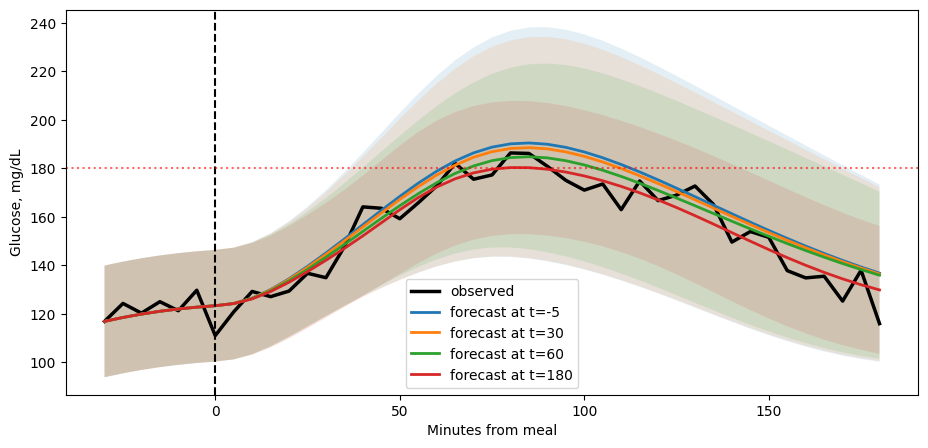

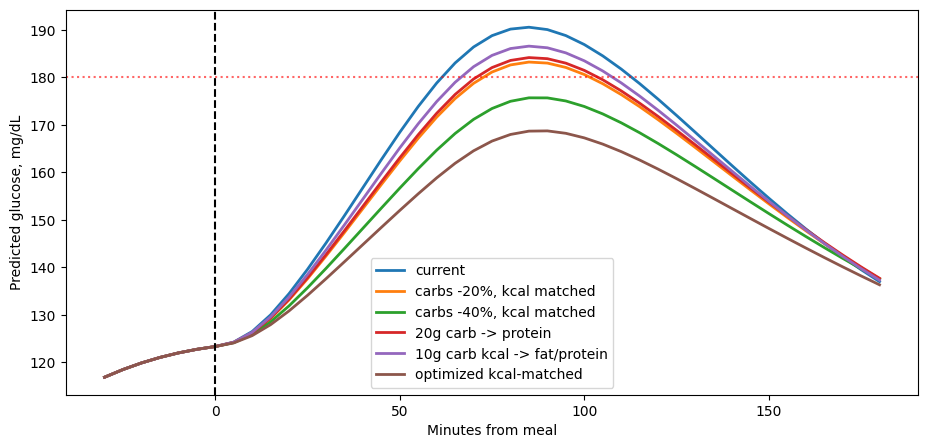

In [24]:

# 5) Run online A/T learning for one held-out meal.
sample = windows[test_idx[2]]
theta = theta_for_sample(sample, population_theta, person_thetas)
prior = predict_at_prior(sample, prior_model)
result = online_at_posterior(sample, theta=theta, prior=prior, n_A=31, n_T=31)

pre_idx = premeal_posterior_index(result["time"])
pre_pred = posterior_predictive(result, posterior_idx=pre_idx)["mean"]
final_pred = posterior_predictive(result, posterior_idx=-1)["mean"]
post = result["time"] >= 0

print("Windows:", len(windows))
print("Train/test:", len(train_idx), len(test_idx))
print("Population theta:", {k: round(population_theta[k], 3) for k in ["period", "zeta"]})
print("Prior A/T:", round(prior["A"], 4), round(prior["T"], 1))
print("Final A/T:", posterior_parameters(result, -1))
print("Premeal RMSE:", np.sqrt(np.mean((pre_pred[post] - sample["glucose"][post]) ** 2)))
print("Online RMSE:", np.sqrt(np.mean((final_pred[post] - sample["glucose"][post]) ** 2)))

plot_online_forecast(result)
display(recommend_meal(sample, theta, prior_model, n_A=21, n_T=21))
plot_counterfactuals(sample, theta, prior_model, n_A=21, n_T=21)

,A_true,T_true,carbs,fat,protein,meal_type,subtype
count,240.000000,240.000000,240.000000,240.000000,240.000000,240,240
unique,NaN,NaN,NaN,NaN,NaN,3,5
top,NaN,NaN,NaN,NaN,NaN,lunch,usual
freq,NaN,NaN,NaN,NaN,NaN,100,96
mean,0.226732,76.260278,75.422910,26.049959,30.304088,NaN,NaN
std,0.097001,52.295607,37.139040,16.093725,12.402729,NaN,NaN
min,0.056126,15.000000,18.957688,3.419370,7.951316,NaN,NaN
25%,0.138012,31.960482,47.104307,14.963060,22.124734,NaN,NaN
50%,0.222282,63.579286,66.154980,21.781416,28.797888,NaN,NaN
75%,0.344058,111.918952,93.977057,33.818801,37.047692,NaN,NaN


,n_seen,A_mean,T_mean,log_A_sd,log_T_sd,coverage_50,coverage_90,median_log_density
0,0,0.055000,55.000000,0.180000,0.160000,0.004167,0.016667,-41.240808
1,5,0.092597,51.530658,0.784838,0.286564,0.108333,0.400000,-3.216776
2,15,0.124767,54.087797,0.763609,0.525647,0.275000,0.766667,-2.131108
3,50,0.166599,58.407483,0.689554,0.677208,0.445833,0.979167,-1.859363
4,150,0.188338,57.727291,0.577439,0.716273,0.437500,0.970833,-1.749179
5,240,0.191616,59.102929,0.539830,0.727900,0.391667,0.958333,-1.708755


online prior learning: 100%|██████████| 12/12 [02:47<00:00, 13.94s/it]


,n_prior_meals,n_eval,population_rmse_mean,population_abs_peak_error_mean,ridge_rmse_mean,ridge_rmse_improvement,ridge_abs_peak_error_mean,ridge_peak_error_improvement,kalman_offset_rmse_mean,kalman_offset_rmse_improvement,kalman_offset_abs_peak_error_mean,kalman_offset_peak_error_improvement,mixed_category_rmse_mean,mixed_category_rmse_improvement,mixed_category_abs_peak_error_mean,mixed_category_peak_error_improvement,kalman_rmse_mean,kalman_rmse_improvement,kalman_abs_peak_error_mean,kalman_peak_error_improvement
0,0,12,13.496688,14.508869,13.496688,0.000000,14.508869,0.000000,13.496688,0.000000,14.508869,0.000000,13.496688,0.000000,14.508869,0.000000,13.496688,0.000000,14.508869,0.000000
1,1,12,13.497938,10.956504,10.620689,2.877249,8.565027,2.391477,10.624447,2.873491,8.629690,2.326814,11.231633,2.266304,8.853966,2.102538,10.710813,2.787125,8.750065,2.206439
2,2,12,11.946484,11.479576,9.115380,2.831104,5.301960,6.177616,9.511156,2.435328,6.141994,5.337582,8.588494,3.357990,6.129228,5.350348,9.223967,2.722517,5.811987,5.667589
3,3,12,16.246572,15.724976,12.069447,4.177126,10.330490,5.394486,11.804513,4.442059,9.224975,6.500001,12.619377,3.627195,10.010552,5.714424,12.114846,4.131726,10.549988,5.174988
4,4,12,12.104890,11.071839,8.987051,3.117839,7.231944,3.839896,8.178832,3.926058,7.505499,3.566340,8.359306,3.745584,6.277220,4.794620,8.894646,3.210245,7.466049,3.605791
5,5,12,10.295966,10.784566,9.705391,0.590575,8.578992,2.205574,10.208860,0.087106,10.946609,-0.162043,9.582530,0.713437,10.368898,0.415668,9.279869,1.016098,8.436921,2.347645
6,6,12,15.220178,16.538351,10.361610,4.858568,12.136320,4.402030,10.411863,4.808315,10.455582,6.082769,10.099562,5.120616,12.234527,4.303823,10.273638,4.946540,12.377353,4.160998
7,7,12,14.033117,14.230815,10.030026,4.003091,6.570927,7.659887,9.480936,4.552181,7.614165,6.616649,10.270310,3.762807,8.612963,5.617852,9.836561,4.196556,7.063461,7.167354
8,8,12,14.755626,15.388289,9.067539,5.688087,6.534991,8.853298,9.898324,4.857302,8.218048,7.170240,9.886928,4.868699,9.004493,6.383796,9.086405,5.669221,7.212138,8.176151
9,9,12,15.844599,14.431071,10.227983,5.616615,7.531134,6.899937,10.828133,5.016465,7.375201,7.055870,10.596356,5.248242,7.626667,6.804404,10.402590,5.442009,7.601732,6.829339


online prior learning: 100%|██████████| 1/1 [03:40<00:00, 220.51s/it]


,n_prior_meals,n_eval,population_rmse_mean,population_abs_peak_error_mean,ridge_rmse_mean,ridge_rmse_improvement,ridge_abs_peak_error_mean,ridge_peak_error_improvement,kalman_offset_rmse_mean,kalman_offset_rmse_improvement,kalman_offset_abs_peak_error_mean,kalman_offset_peak_error_improvement,mixed_category_rmse_mean,mixed_category_rmse_improvement,mixed_category_abs_peak_error_mean,mixed_category_peak_error_improvement,kalman_rmse_mean,kalman_rmse_improvement,kalman_abs_peak_error_mean,kalman_peak_error_improvement
0,0,1,9.700936,1.397176,9.700936,0.000000,1.397176,0.000000,9.700936,0.000000,1.397176,0.000000,9.700936,0.000000,1.397176,0.000000,9.700936,0.000000,1.397176,0.000000
1,1,1,12.543979,12.521516,9.994871,2.549108,7.211823,5.309692,10.408336,2.135644,8.100833,4.420683,9.796606,2.747373,6.781219,5.740297,9.991163,2.552816,7.203781,5.317735
2,2,1,23.152762,23.136831,19.079372,4.073390,15.448689,7.688142,13.353096,9.799666,4.236578,18.900253,19.273316,3.879446,16.281660,6.855171,19.156983,3.995779,15.584662,7.552168
3,3,1,7.707146,5.475577,8.319218,-0.612072,8.844004,-3.368428,9.661029,-1.953884,12.112859,-6.637282,6.804596,0.902549,4.652233,0.823344,8.288147,-0.581001,8.776068,-3.300491
4,4,1,6.705740,4.424841,9.399698,-2.693957,8.856471,-4.431631,10.021253,-3.315512,9.646454,-5.221613,8.624117,-1.918377,7.687678,-3.262838,9.565289,-2.859549,9.107842,-4.683001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,245,1,10.848332,18.315059,14.698581,-3.850249,32.829616,-14.514556,12.060330,-1.211998,27.513995,-9.198935,14.153854,-3.305521,29.620869,-11.305809,11.988693,-1.140360,27.358648,-9.043589
246,246,1,8.736101,12.453457,8.522489,0.213613,17.327939,-4.874481,8.980295,-0.244194,19.062094,-6.608637,5.811548,2.924553,12.560911,-0.107454,8.450007,0.286095,17.913271,-5.459814
247,247,1,7.283143,10.716807,9.537249,-2.254107,20.789611,-10.072803,7.459961,-0.176818,15.332906,-4.616098,8.601458,-1.318315,18.924335,-8.207528,8.886991,-1.603848,19.613001,-8.896194
248,248,1,14.174301,26.792528,21.898263,-7.723962,43.217166,-16.424638,16.205344,-2.031043,33.640889,-6.848362,16.674526,-2.500225,34.408009,-7.615481,20.158935,-5.984634,40.553695,-13.761167


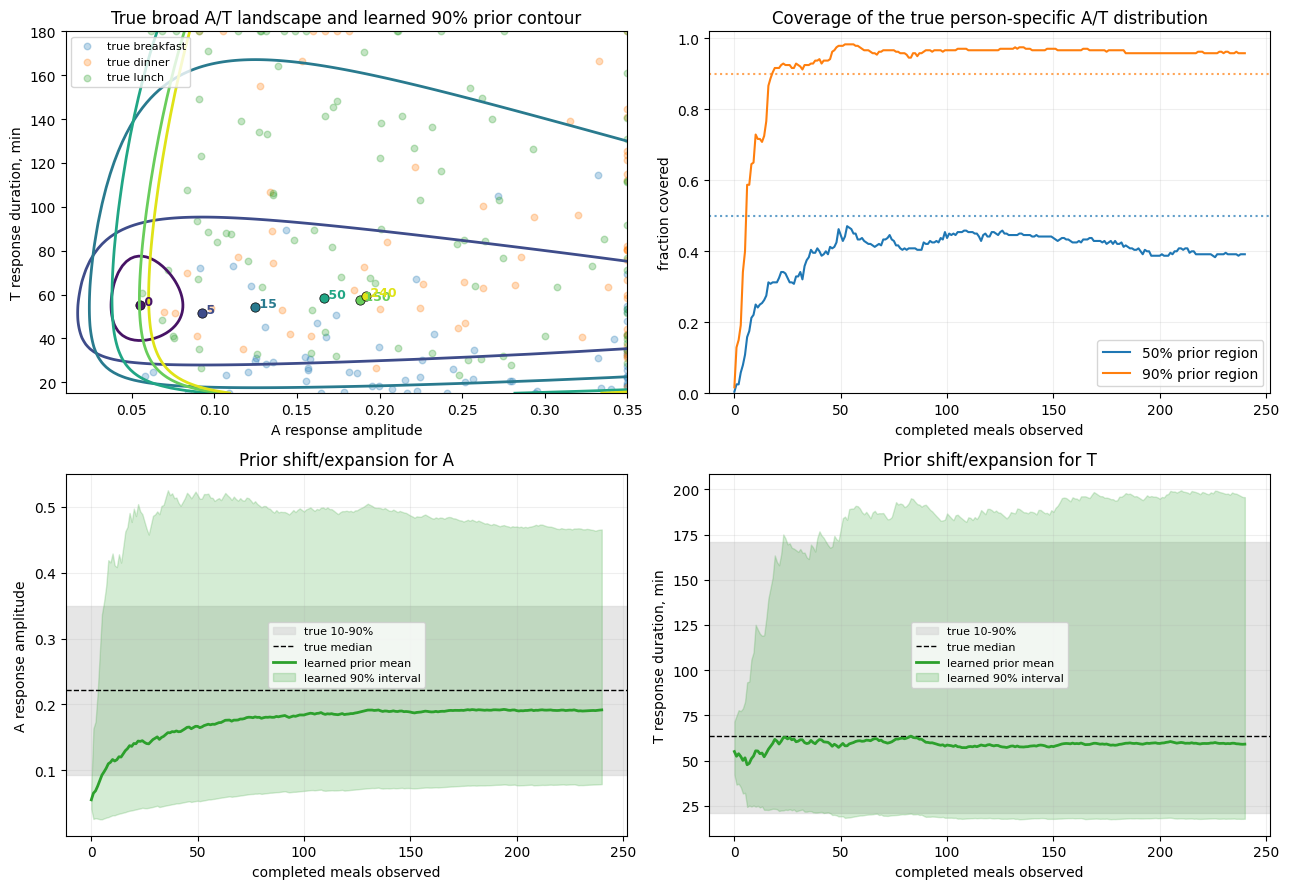

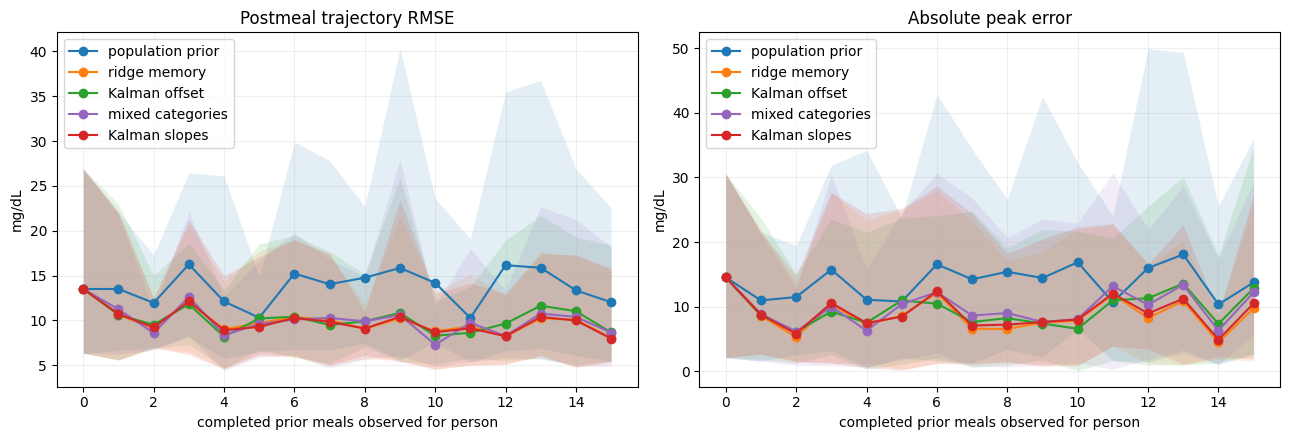

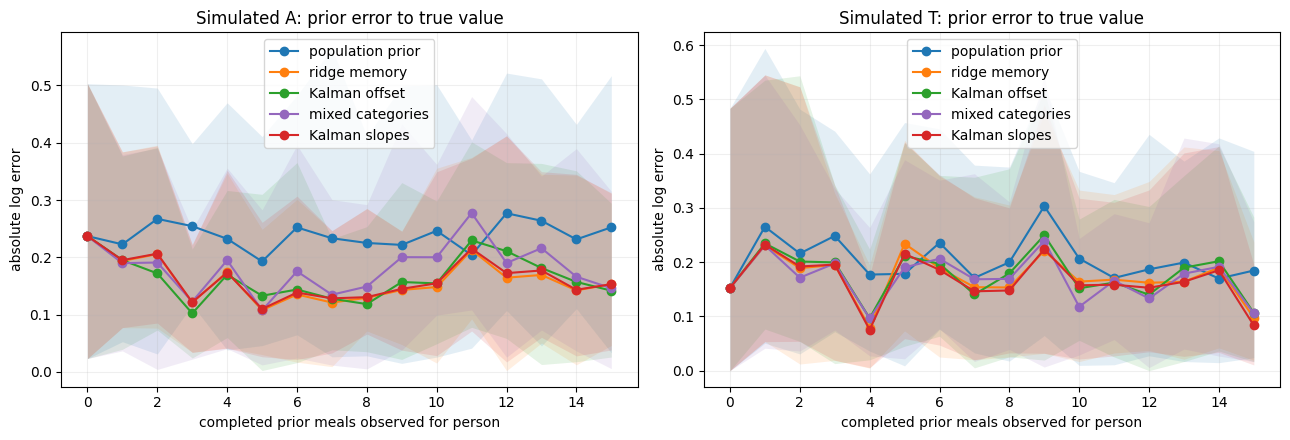

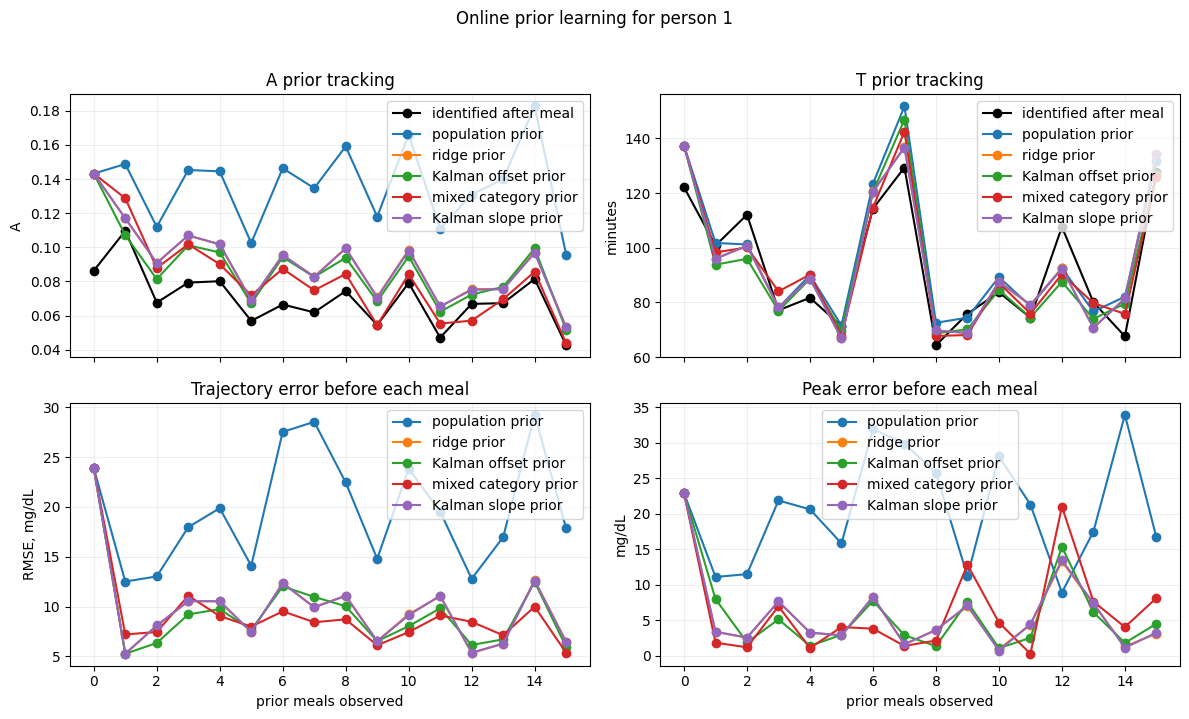

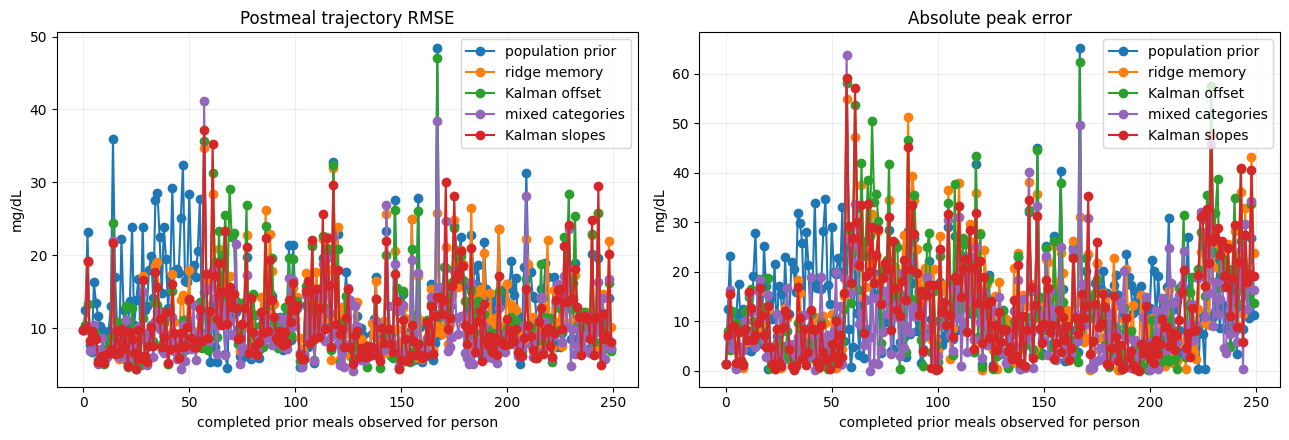

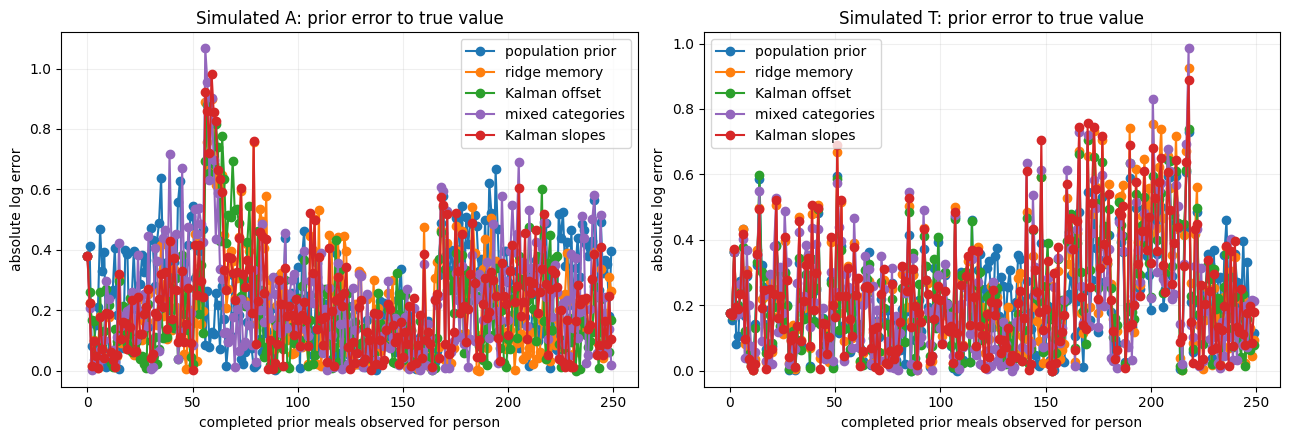

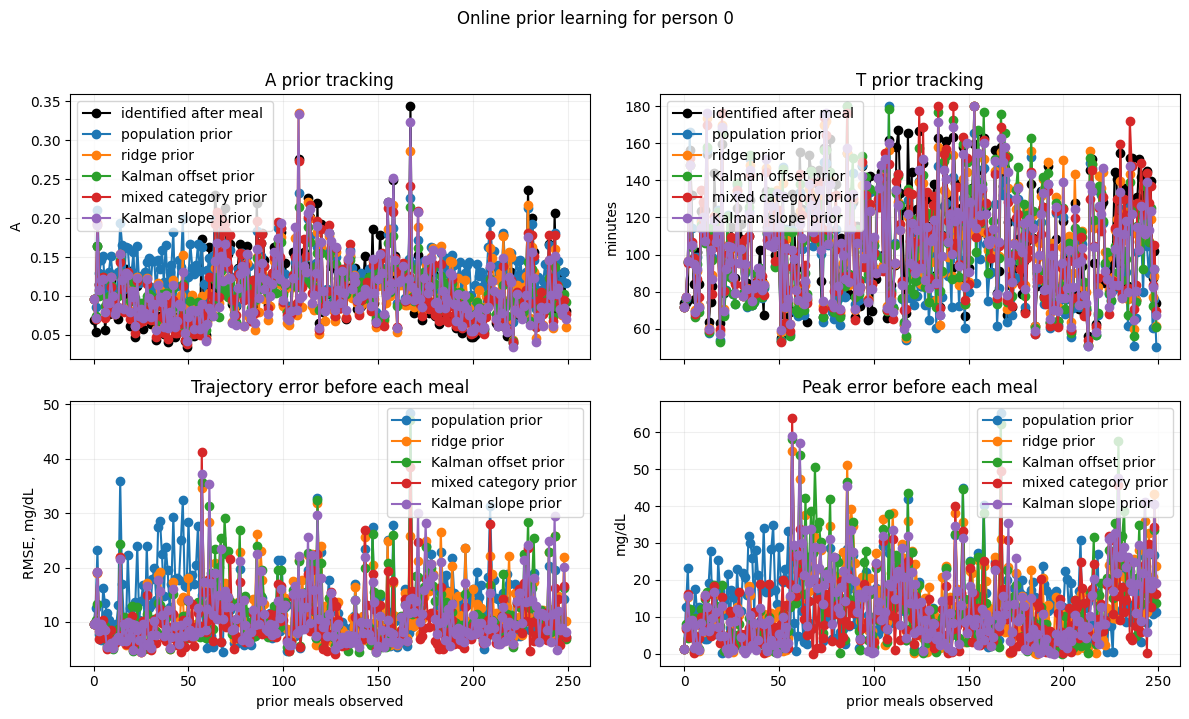

In [26]:
# =========================================================
# Synthetic Diagnostic: Biased Prior Learns a Broad A/T Distribution
# =========================================================

RUN_BROAD_AT_PRIOR_SHIFT_DIAGNOSTIC = True

if RUN_BROAD_AT_PRIOR_SHIFT_DIAGNOSTIC:
    import sys
    from pathlib import Path

    project_root = Path.cwd()
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "scripts" / "broad_at_prior_diagnostic.py").exists():
            project_root = candidate
            break
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    from scripts.broad_at_prior_diagnostic import (
        broad_at_snapshot_table,
        plot_broad_at_prior_shift_diagnostic,
        run_broad_at_prior_shift_diagnostic,
    )

    broad_at_prior_diagnostic = run_broad_at_prior_shift_diagnostic()
    display(
        broad_at_prior_diagnostic["truth"][[
            "A_true",
            "T_true",
            "carbs",
            "fat",
            "protein",
            "meal_type",
            "subtype",
        ]].describe(include="all")
    )
    display(broad_at_snapshot_table(broad_at_prior_diagnostic))
    plot_broad_at_prior_shift_diagnostic(broad_at_prior_diagnostic)


# =========================================================
# Quick Demo: Does the Prior Learn Across Meals?
# =========================================================

RUN_ONLINE_PRIOR_LEARNING_DEMO = True

if RUN_MINIMAL_DEMO and RUN_ONLINE_PRIOR_LEARNING_DEMO:
    online_learning_df = evaluate_online_prior_learning(
        windows,
        train_idx + test_idx,
        prior_model=prior_model,
        population_theta=population_theta,
        person_thetas=person_thetas,
        max_people=12,
        max_meals_per_person=16,
        min_meals_per_person=6,
        n_A=13,
        n_T=13,
        random_state=7,
    )

    display(summarize_online_learning_curve(online_learning_df))
    plot_online_learning_curve(online_learning_df)
    if str(DATA_SOURCE).lower().startswith("sim"):
        plot_simulated_truth_learning_curve(online_learning_df)
    plot_online_person_learning_trace(online_learning_df)

    pooled_learning_df = evaluate_online_prior_learning(
        windows,
        train_idx + test_idx,
        prior_model=prior_model,
        population_theta=population_theta,
        person_thetas=person_thetas,
        max_people=None,
        max_meals_per_person=250,
        min_meals_per_person=20,
        n_A=13,
        n_T=13,
        random_state=7,
        pool_people_as_one=True,
        pooled_person_id=0,
    )

    display(summarize_online_learning_curve(pooled_learning_df))
    plot_online_learning_curve(pooled_learning_df)
    if str(DATA_SOURCE).lower().startswith("sim"):
        plot_simulated_truth_learning_curve(pooled_learning_df)
    plot_online_person_learning_trace(pooled_learning_df, person_id=0)
